# Table of contents

* **Introduction**
* **Objective**
* **Convolutional Neural Networks (CNNs) ...**
* **Data Dictionary**
* **Pipeline Overview**
* **Approach**
* **Setup Environments**
* **Data Loading**
* **Exploratory Data Analysis (EDA)**
* **Feature Engineering**
* **Model Training**
    * Model Architecture, Model Building (Keras), and Model training
    * Model Architecture, Model Building (TensorFlow custom function), and Model Training
* **Model Evaluation**
* **Conclusion**
* **References**

# Introduction

This project details the process for implementing a Convolutional Neural Network (CNN) using the TensorFlow/Keras framework, focusing on the well-known FashionMNIST dataset. FashionMNIST serves as an ideal entry point for image classification tasks, comprising 70,000 grayscale images of 28x28 pixels, representing ten distinct clothing categories. CNNs are specifically chosen for this task due to their inherent ability to learn spatial hierarchies of features—starting from simple edges and curves in early layers, progressing to complex patterns in deeper layers—making them highly effective for computer vision problems.

# Objective

The primary objective is to design and implement a robust CNN model capable of classifying the 28x28 grayscale images into their correct fashion categories. Success is defined by achieving strong generalization, ensuring the model performs reliably on unseen test data. This involves meticulous data handling, architecting an efficient deep learning model, applying essential regularization techniques like early stopping to prevent overfitting, and conducting a thorough, multi-faceted evaluation to understand the model's strengths and weaknesses across all ten classes. A secondary objective involves enhancing model transparency through interpretability methods, such as visualizing learned filters and mapping the decision space.

# Convolutional Neural Networks (CNNs) FOundations

A Convolutional Neural Network (CNN) is a specialized type of deep learning model primarily designed to process and analyze structured grid-like data, such as images. They are highly effective at automatically learning spatial hierarchies of features from low-level details (edges and textures) to high-level concepts (objects and faces).

**How CNNs Work**

A CNN operates by applying a sequence of specialized layers to the input data. Its effectiveness stems from three fundamental concepts: sparse connectivity, parameter sharing, and equivariant representations.

**Convolutional Layer (Feature Extraction)**

This is the core building block of a CNN. It performs feature extraction by detecting patterns in local regions of the input:

- Kernel (Filter): A small matrix of weights (e.g., $3 \times 3$) that slides across the input data (e.g., an image). The kernel performs an element-wise multiplication with the small region of the input it covers, and the results are summed up to produce a single output value.
- Convolution Operation: This sliding process generates a new matrix called a feature map (or activation map), which highlights where specific features (like vertical edges or corners) are located in the input.
- Activation Function (ReLU): Immediately after the convolution, a non-linear activation function, typically the Rectified Linear Unit ($\text{ReLU}(z) = \max(0, z)$), is applied element-wise to the feature map. This introduces non-linearity, allowing the network to learn more complex relationships.

**Pooling Layer (Dimensionality Reduction)**

This layer is inserted between successive convolutional layers to progressively reduce the spatial dimensions (width and height) of the feature maps, which helps to:
- Reduce Computational Load: Fewer parameters and computations are needed in subsequent layers.
- Control Overfitting: Simplifies the model.
- Achieve Translation Invariance: The network becomes more robust to small shifts or distortions in the input image.

The most common method is Max Pooling, which takes the maximum value from a cluster of neurons in the feature map, thus retaining the most prominent feature response in that local region.

**Fully Connected Layer (Classification)** 

After several alternating convolutional and pooling layers have extracted complex features, the final feature maps are flattened into a single vector. This vector is fed into one or more standard Fully Connected (Dense) layers. These layers, identical to those in a traditional neural network, use the high-level features learned by the CNN layers to perform the final classification task (e.g., deciding if the image contains a cat, dog, or car).

**Types of Convolutional Neural Networks**

The term "types" of CNN often refers to different architectural variants that adapt the standard CNN structure for various tasks or data types. Some of the most notable types and architectures include:

**1. By Dimensionality of Convolution**

This categorization depends on the shape of the data and the direction the filter slides:
- 1D CNN: Used for sequence data like time-series or signals (e.g., audio, medical data, natural language processing). The filter slides along a single dimension.
- 2D CNN: The standard form, used for images (2D grids). The filter slides across the height and width of the input.
- 3D CNN: Used for volumetric data (like MRI scans) or video (which adds a temporal dimension to space). The filter slides across height, width, and depth (or time).

**2. By Architecture and Design Principles**

These are specialized designs optimized for specific performance goals (depth, speed, or accuracy):
- LeNet: One of the earliest and foundational CNN architectures, primarily used for handwritten digit recognition.
- AlexNet: A pioneering deep CNN that demonstrated the power of the model on large-scale datasets (ImageNet), featuring multiple convolutional layers, ReLU activation, and local response normalization.
- VGGNet: Known for its simplicity, using very small ($3 \times 3$) filters throughout the entire network, emphasizing the depth of the network.
- ResNet (Residual Network): Introduced Skip Connections (or residual connections) to allow the gradient to flow around non-linear layers. This solved the degradation problem, enabling the training of extremely deep networks (hundreds of layers).
- Inception (GoogLeNet): Introduced the Inception Module, which performs multiple parallel convolutions (with $1 \times 1, 3 \times 3, 5 \times 5$ kernels, and pooling) on the same input block.This allows the network to automatically choose the best convolutional size for the input data.
- MobileNet / EfficientNet: Designed for mobile and embedded vision applications. They prioritize efficiency and speed by using techniques like depthwise separable convolutions to drastically reduce the number of parameters and computational cost while maintaining high accuracy

# Data Dictionary

**About Dataset**

Image Format is a single row in the CSV file. The first column is the label (0-9, representing the clothing type). Each image is 28 pixels in height and 28 pixels in width, for a total of 784 pixels in total. Each pixel has a single pixel-value associated with it, indicating the lightness or darkness of that pixel, with higher numbers meaning darker. This pixel-value is an integer between 0 and 255. The training and test data sets have 785 columns. The first column consists of the class labels (see above), and represents the article of clothing. The rest of the columns contain the pixel-values of the associated image. Training and Test sets contains 60,000 and 10,000 images, respectively.

To locate a pixel on the image, suppose that we have decomposed $x$ as $x = i * 28 + j$, where i and j are integers between 0 and 27. The pixel is located on row i and column j of a 28 x 28 matrix.
For example, pixel31 indicates the pixel that is in the fourth column from the left, and the second row from the top, as in the ascii-diagram below.

**Labels**

Each training and test example is assigned to one of the following labels:

* 0 T-shirt/top
* 1 Trouser
* 2 Pullover
* 3 Dress
* 4 Coat
* 5 Sandal
* 6 Shirt
* 7 Sneaker
* 8 Bag
* 9 Ankle boot

**[Dataset Link](https://www.kaggle.com/datasets/zalando-research/fashionmnist)**

# Pipeline Overview

The project follows a standard machine learning workflow adapted for deep image classification.

- Data Loading and Initial Exploration: Raw data is imported, and its structure is inspected. Sample images are visualized to confirm data integrity, and basic statistics regarding pixel distributions are assessed.
- Preprocessing: Raw pixel data is transformed to a standardized numerical format compatible with CNN input requirements.
- Model Building: Two distinct CNN architectures are defined: a standard, sequential Keras model utilizing the ReLU activation function, and a customized variant incorporating a user-defined layer that employs the Leaky ReLU function.
- Training: Models are optimized using the Adam algorithm, incorporating a regularization strategy based on Early Stopping to govern the training duration based on validation loss.
- Evaluation: Performance is quantitatively measured using a range of classification metrics.
- Interpretability: Model behavior is analyzed through the visualization of internal feature maps and the mapping of the classification boundary in a reduced feature space.

# Approach

**Preprocessing Pipeline Approach**

The preprocessing phase ensures the raw image data is suitable for the computational requirements of a CNN.
- Data Acquisition: Features (784 pixel columns) and the target variable (label) are separated from the raw CSV data files for both the training and test sets.
- Feature Normalization: Pixel intensity values, initially ranging from 0 to 255, are scaled down to the interval [0, 1] by division by 255.0. This normalization is critical as it stabilizes the magnitude of inputs, preventing features with large values from dominating the gradient updates during training.
- Dimensionality Reshaping: Convolutional layers require a specific input tensor shape. The flattened 784-dimensional vectors are reshaped into the standard 4D tensor format for 2D convolution: (number of samples, 28, 28, 1), where the final dimension represents the single color channel (grayscale).
- Label Preparation: The categorical labels (0–9) are maintained in their integer format, which is the necessary input structure for the sparse categorical crossentropy loss function, avoiding the need for one-hot encoding.

**Model Training Approach**

Model training involves defining the architecture, selecting the optimization strategy, and implementing effective regularization.

**Standard Model Architecture**

The architecture relies on a sequence of convolutional and pooling layers for feature extraction:
- Two blocks of Conv2D layers (32 and 64 filters, 3x3 kernel size, 'same' padding) are used to detect increasingly complex local patterns.
- Each Conv2D layer is followed by a MaxPooling2D layer (2x2 pool size) to reduce the spatial dimensions and increase translational invariance.
- The output is Flattened and passed through two Dense (fully connected) layers (128 and 64 neurons), both utilizing the standard ReLU activation function.
- The final output layer uses 10 neurons and the Softmax activation function to generate class probabilities for the ten categories.

**Custom Model Variant**

A custom model variant explores alternative activation functions by replacing an intermediate dense layer with a CustomDenseLayer that employs the Leaky ReLU activation function (with a negative slope coefficient $\alpha=0.2$). This modification addresses the "dying ReLU" problem by allowing small, non-zero gradients even for negative inputs.

**Compilation and Regularization**

- Optimizer: The Adam optimizer is selected for its efficiency in handling sparse gradients and adaptive learning rate capabilities.
- Loss Function: Sparse Categorical Crossentropy is used, appropriate for multi-class classification where the labels are integers.
- Regularization: To combat overfitting, Early Stopping is implemented. The training process monitors the validation loss and halts training if no improvement is observed over a specified number of epochs (patience=8). The best model weights from the optimal epoch are restored before final evaluation. Training runs for a maximum of 100 epochs with a batch size of 64.

**Model Evaluation Approach**

A comprehensive evaluation determines the model's true performance beyond simple accuracy.
- Fundamental Metrics: The model's final performance is measured on the independent test set, yielding the terminal loss and accuracy. Predictions are generated to compute standard metrics, including accuracy and macro-averaged precision, recall, and F1-score.
- Multi-class ROC Analysis: The Area Under the Receiver Operating Characteristic Curve (ROC-AUC) is computed using the One-vs-Rest strategy, providing a measure of the model's ability to discriminate between each class and all other classes combined.
- Misclassification Analysis: A Confusion Matrix is generated and visualized to explicitly identify which classes are most frequently mistaken for others, revealing systemic errors (e.g., mistaking trousers for skirts).
- Probability Threshold Analysis: Per-class Precision-Recall (PR) curves are plotted with the Area Under the Curve (PR-AUC) reported. These plots are critical for assessing performance on specific, potentially more challenging classes, particularly in the context of varying decision thresholds.
- Interpretability in Latent Space: To visualize what the model has learned, feature representations are extracted from an intermediate dense layer. Principal Component Analysis (PCA) is applied to these high-dimensional features, reducing the dimensionality to 2D. This allows the model's decision boundaries to be reconstructed and plotted alongside the test samples in this reduced space, offering geometric insight into the model's classification strategy.

# Setup Environments

**Import Libraries**

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch import nn
import torch.nn.functional as F
import torch.optim as optim

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, ReLU, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    precision_recall_curve,
    auc,
    roc_curve
)
from sklearn.decomposition import PCA

print(f"TensorFlow Version: {tf.__version__}")

2025-11-12 17:58:08.830388: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762970289.077816      38 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762970289.151312      38 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


TensorFlow Version: 2.18.0


# Data Loading

The process begins by loading the training and testing datasets from CSV files into Pandas DataFrames.

In [3]:
train = pd.read_csv('/kaggle/input/fashionmnist/fashion-mnist_train.csv')
test = pd.read_csv('/kaggle/input/fashionmnist/fashion-mnist_test.csv')
train

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59996,1,0,0,0,0,0,0,0,0,0,...,73,0,0,0,0,0,0,0,0,0
59997,8,0,0,0,0,0,0,0,0,0,...,160,162,163,135,94,0,0,0,0,0
59998,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Each row in the DataFrame represents a single image, comprising 785 columns: the first column, label, contains the class identity (0-9), and the subsequent 784 columns (from pixel1 to pixel784) represent the individual pixel intensity values of the $28 \times 28$ image.

# Exploratory Data Analysis (EDA)

**Basic Information**

In [4]:
train.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


The use of `train.info()` confirms that all $785$ columns are of the $\text{int64}$ data type, verifying that there are no missing values (NaNs) and the dataset is ready for basic analysis. 

In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 785 entries, label to pixel784
dtypes: int64(785)
memory usage: 359.3 MB


The output of `train.describe()` provides statistical summaries, showing that the majority of pixel values have a minimum of $0$ (black) and a maximum of $255$ (white), with a large number of pixels concentrated at the minimum, indicating a sparse representation common in grayscale images with dark backgrounds.

In [6]:
train.describe()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
count,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,...,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.00000
mean,4.500000,0.000900,0.006150,0.035333,0.101933,0.247967,0.411467,0.805767,2.198283,5.682000,...,34.625400,23.300683,16.588267,17.869433,22.814817,17.911483,8.520633,2.753300,0.855517,0.07025
std,2.872305,0.094689,0.271011,1.222324,2.452871,4.306912,5.836188,8.215169,14.093378,23.819481,...,57.545242,48.854427,41.979611,43.966032,51.830477,45.149388,29.614859,17.397652,9.356960,2.12587
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,4.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,58.000000,9.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,9.000000,16.000000,36.000000,226.000000,164.000000,227.000000,230.000000,224.000000,255.000000,254.000000,...,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,170.00000


**Distribution of Target Labels**

Understanding the distribution of the target variable is critical in any classification task.
- Target Labels: The dataset contains $10$ unique classes, identified by integer labels 0 through 9.
- Class Balance: The analysis of `train['label'].value_counts(normalize=True)*100` demonstrates a perfectly balanced dataset, with each of the $10$ classes (e.g., 'T-shirt/top', 'Trouser', 'Sandal') accounting for exactly $10\%$ of the $60,000$ training samples. This uniform distribution simplifies model evaluation, as classification accuracy will not be biased toward any single class.

In [7]:
label = train['label']
label = set(label)
label

{0, 1, 2, 3, 4, 5, 6, 7, 8, 9}

In [8]:
train['label'].value_counts(normalize=True)*100

label
2    10.0
9    10.0
6    10.0
0    10.0
3    10.0
4    10.0
5    10.0
8    10.0
7    10.0
1    10.0
Name: proportion, dtype: float64

**Distribution of Pixel Intensities**


--- Distribution of Pixel Intensities in Training Data ---
Shape of all_pixel_values: (47040000,)


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


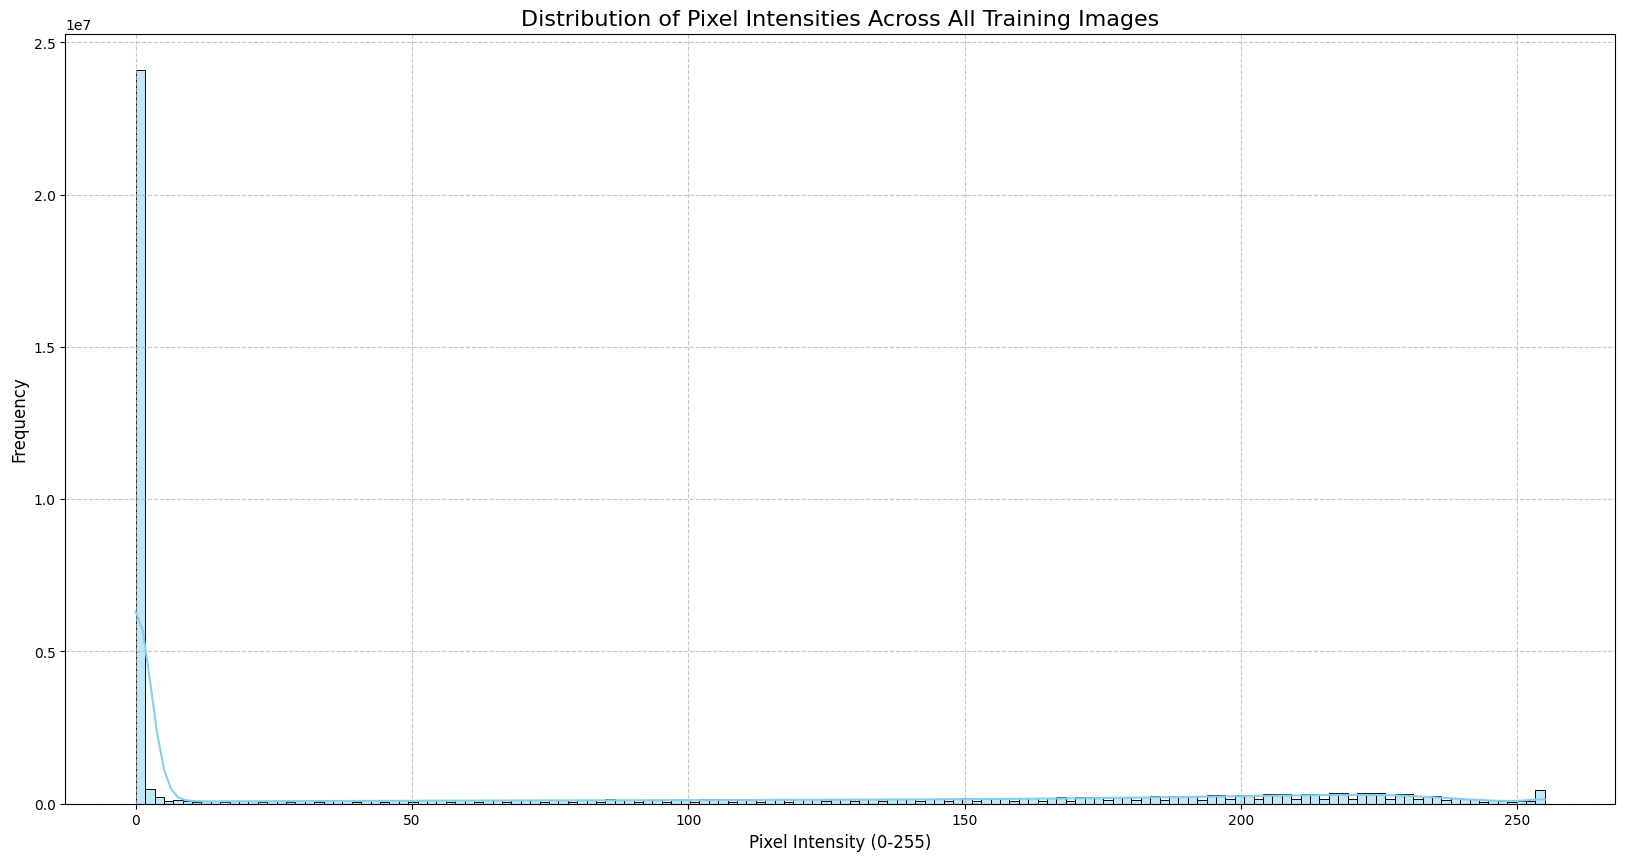

In [ ]:
print("\n--- Distribution of Pixel Intensities in Training Data ---")

pixel_data = train.drop('label', axis=1)

all_pixel_values = pixel_data.values.flatten()

all_pixel_values = all_pixel_values[~np.isinf(all_pixel_values)]
all_pixel_values = all_pixel_values[~np.isnan(all_pixel_values)]

print(f"Shape of all_pixel_values: {all_pixel_values.shape}")
if all_pixel_values.size > 0:
    plt.figure(figsize=(20, 10))
    sns.histplot(all_pixel_values, bins=150, kde=True, color='skyblue')
    plt.title('Distribution of Pixel Intensities Across All Training Images', fontsize=16)
    plt.xlabel('Pixel Intensity (0-255)', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()
else:
    print("No pixel data available to plot the distribution.")

The histogram  of all 47 million pixel values across the training set reveals critical quantitative information regarding the data's composition:
- Dominant Intensity at Zero (Black): The distribution is heavily skewed toward the left, with an overwhelming spike in frequency at or near an intensity value of $\mathbf{0}$. This confirms the expectation for grayscale images of objects on a pure black background, where the background pixels constitute the vast majority of the data points.
- Secondary Peak at 255 (White): A second, much smaller, but noticeable spike appears near an intensity value of $\mathbf{255}$. This represents the brightest parts of the garments themselves, typically outlines or dominant areas of the apparel.
- Sparsity of Mid-Range Values: The low frequency across the mid-range of intensities ($\approx 1$ to $200$) suggests that most of the non-background pixels are concentrated at the brightest end, confirming the high contrast nature of the images.This visualization reinforces the necessity of Data Preprocessing, specifically Normalization. Before training a neural network, the pixel values (currently in the range $0$ to $255$) should be scaled down, typically to the range $0$ to $1$, to ensure that all features contribute equally to the gradient descent process and to improve the convergence speed and stability of the model.

**Dataset Visualization**

The visualization of sample images  provides an essential qualitative assessment. By reshaping the $1 \times 784$ pixel vectors back into $28 \times 28$ arrays and plotting them using a grayscale colormap (cmap='gray'), the distinct visual characteristics of each apparel item are confirmed. For example, the clear distinction between a 'Trouser' (long, vertical shape) and a 'Sandal' (flat, horizontal shape) informs the expectation that a well-designed image classification model should be able to capture these high-level features.

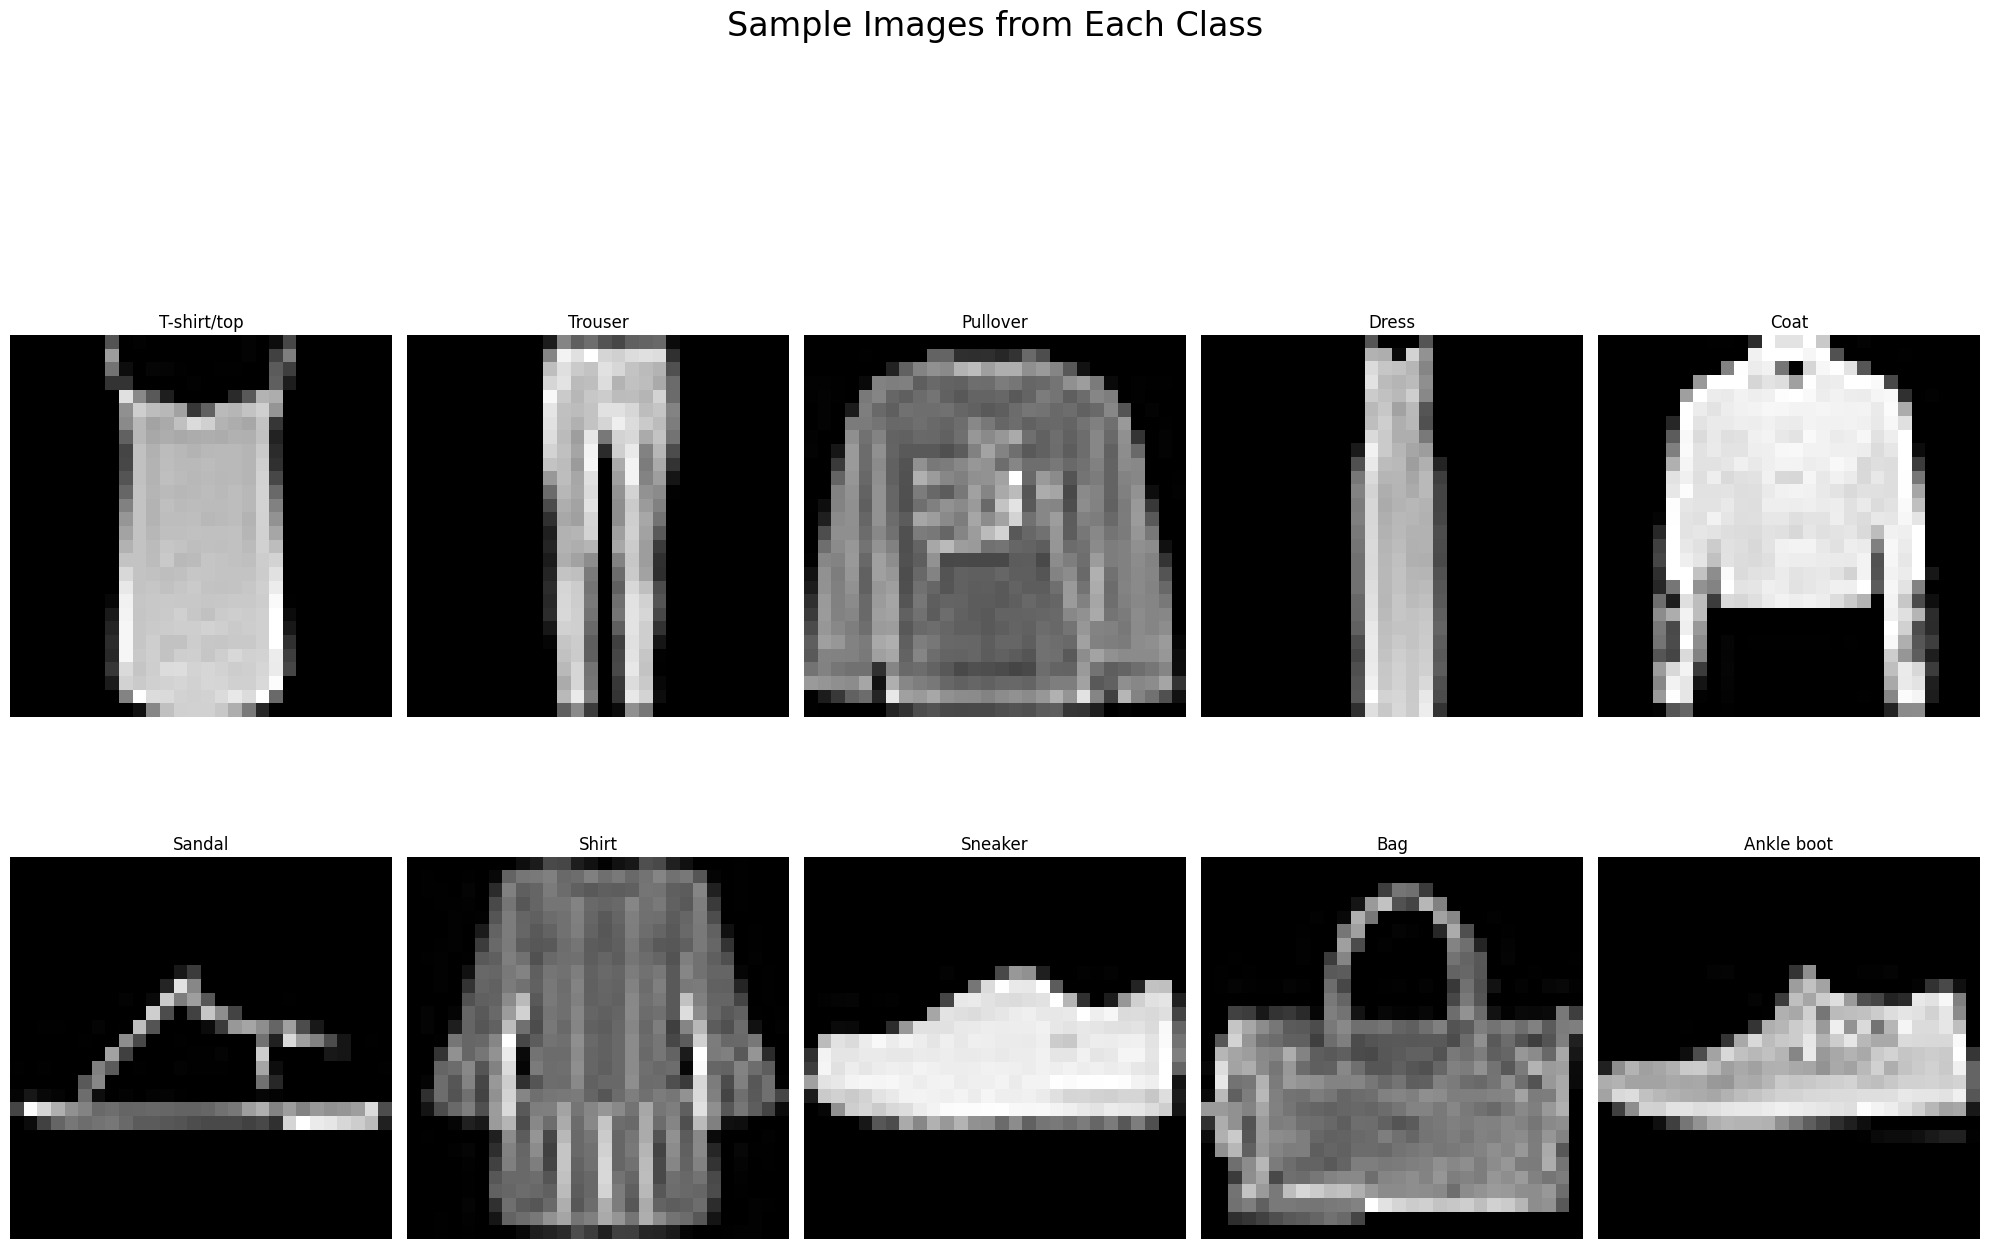

In [ ]:
y = train['label']

pixel_cols = train.drop('label', axis=1).columns.tolist()

label_dict = {
    0: 'T-shirt/top',
    1: 'Trouser',
    2: 'Pullover',
    3: 'Dress',
    4: 'Coat',
    5: 'Sandal',
    6: 'Shirt',
    7: 'Sneaker',
    8: 'Bag',
    9: 'Ankle boot'
}

plt.figure(figsize=(20, 15))
for i, class_id in enumerate(label_dict.keys()):
    plt.subplot(2, 5, i + 1)

    if isinstance(y, pd.Series):
        samples_for_class = train.loc[y == class_id, pixel_cols]
    else:
        samples_for_class = train.loc[pd.Series(y) == class_id, pixel_cols]

    if not samples_for_class.empty:
        sample = samples_for_class.sample(1)
        image_array = np.reshape(sample.values[0], (28, 28))

        plt.gca().imshow(image_array, cmap='gray', vmin=0, vmax=255)
        plt.title(label_dict[class_id])
        plt.axis('off')
    else:
        plt.title(f"No samples for {label_dict[class_id]}")
        plt.axis('off')

plt.suptitle('Sample Images from Each Class\n', fontsize=24)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Feature Engineering

This phase of the analysis involves essential data manipulation steps to transform the raw, tabular dataset into the structured format required for training a Convolutional Neural Network (CNN). This includes the foundational concepts of dataset splitting, normalization, and reshaping for spatial processing.

**Features and Target Labels Splitting**

The initial step involves cleanly separating the feature data ($\mathbf{X}$) from the target labels ($\mathbf{Y}$) for both the training and testing sets.

In [ ]:
x_train_raw = train.drop('label', axis=1)
y_train_raw = train['label']
x_test_raw = test.drop('label', axis=1)
y_test_raw = test['label']

print("X_train shape:", x_train_raw.shape)
print("y_train shape:", x_test_raw.shape)
print("X_test shape:", x_test_raw.shape)
print("y_test shape:", y_test_raw.shape)

X_train shape: (60000, 784)
y_train shape: (10000, 784)
X_test shape: (10000, 784)
y_test shape: (10000,)


**Data Normalization and Reshape**

This is the most crucial preprocessing step, involving two core concepts: normalization and dimensional reshaping.

**Normalization**

Raw pixel intensities in the FashionMNIST dataset range from 0 to 255 (where 0 is black and 255 is white). Large input values can lead to numerical instability during training. The objective of normalization is to scale these values down to a smaller, standardized range, typically `[0, 1]`, by dividing all pixel values by the maximum possible value (255.0). This scaling helps to ensure that the loss function behaves well and stabilizes the gradient descent process. When inputs are small, the gradients computed during backpropagation are more stable, leading to faster convergence and better training performance.

**Reshaping for CNN Input**

Convolutional layers in deep learning frameworks like Keras/TensorFlow operate on four-dimensional tensors, requiring the input to be structured as: (number of samples, height, width, channels).
- Original Structure: The normalized image data is currently flat, having the shape $\text{(samples, } 784\text{)}$.
- Reshaping Operation: The data is explicitly reshaped into $\text{(samples, } 28, 28, 1\text{)}$.
    - 28 $\times$ 28: Represents the physical dimensions (height and width) of the grayscale images.
    - 1: Represents the number of color channels. Since FashionMNIST images are grayscale, they have a channel depth of 1, as opposed to RGB images which have a depth of 3.

This transformation (`x_train_cnn and x_test_cnn`) organizes the features spatially, allowing the convolutional kernels to perform 2D feature extraction (detecting edges and patterns) across the local neighborhood of pixels.

**Target Label Format**

The target labels (`y_train_cnn and y_test_cnn`) are retained in their integer format (0 to 9). This is the required format when using the sparse categorical crossentropy loss function, a common practice in multi-class classification that saves memory and computation compared to converting labels to a one-hot encoded vector.

In [ ]:
x_train_normalized = x_train_raw.values / 255.0
x_test_normalized = x_test_raw.values / 255.0

x_train_cnn = x_train_normalized.reshape(-1, 28, 28, 1)
x_test_cnn = x_test_normalized.reshape(-1, 28, 28, 1)

y_train_keras = y_train_raw.values
y_test_keras = y_test_raw.values

print(f"x_train_cnn shape: {x_train_cnn.shape}")
print(f"y_train_keras shape: {y_train_keras.shape}")
print(f"x_test_cnn shape: {x_test_cnn.shape}")
print(f"y_test_keras shape: {y_test_keras.shape}")
print("="*40 + "\n")

x_train_cnn shape: (60000, 28, 28, 1)
y_train_keras shape: (60000,)
x_test_cnn shape: (10000, 28, 28, 1)
y_test_keras shape: (10000,)



# Model Training

## Model Architecture, Model Building (Keras), and Model training

The subsequent phase involves defining, compiling, and training a Convolutional Neural Network (CNN) architecture to classify the prepared Fashion-MNIST image data. This process relies on key deep learning principles to achieve high classification accuracy.

**Model Architecture and Construction**

A sequential CNN model is constructed, leveraging layers optimized for image data:
- Input Layer: Explicitly defines the input shape as $(28, 28, 1)$, matching the normalized and reshaped grayscale images.
- Convolutional Blocks (Feature Learning): The architecture employs two blocks, each consisting of a `Conv2D` layer followed by a `MaxPooling2D` layer.
    - Conv2D: These layers (with 32 and 64 filters, respectively) use $3 \times 3$ kernels and the ReLU activation function. The convolution operation extracts hierarchical features—initially learning simple edges and textures, and in deeper layers, combining these to form complex shapes.
    - MaxPooling2D: This layer performs subsampling, reducing the spatial dimensions (height and width) by a factor of $2 \times 2$. This reduces the computational load and provides a degree of translation invariance, making the network robust to minor shifts in the input image.
- Flattening: The 2D feature maps are converted into a $1D$ vector, preparing the data for the standard dense layers.
- Dense Layers (Classification): A sequence of fully connected layers (128, 64 neurons) and an output layer perform the final classification.
- Output Layer: Contains $10$ neurons (equal to the number of classes) and uses the Softmax activation function. Softmax converts the raw output scores (logits) into a probability distribution over the $10$ classes, ensuring the output probabilities sum to 1.

**Model Compilation and Training Strategy**

The model is configured using an appropriate optimizer, loss function, and regularization technique.
- Optimizer: The Adam optimizer is chosen. It is an adaptive learning rate optimization algorithm that efficiently combines the benefits of RMSProp and Momentum, generally leading to faster convergence than standard Stochastic Gradient Descent (SGD). A learning rate of $0.001$ is specified.
- Loss Function: Sparse Categorical Cross-Entropy is used. This is appropriate because the target labels ($\mathbf{Y}$) are integer class indices (0-9) rather than one-hot encoded vectors, making the training process slightly more memory-efficient. The loss function quantifies the discrepancy between the predicted probability distribution and the true label.
- Regularization via Early Stopping: An Early Stopping callback is implemented to prevent overfitting. It monitors the $\mathbf{validation\ loss}$ and halts training if no improvement is observed for a set number of epochs (`patience=8`). Upon stopping, the weights from the epoch that achieved the lowest validation loss are restored, ensuring the final model is the optimal trade-off between training performance and generalization ability.

In [ ]:
num_classes = len(np.unique(y_train_keras))

model = Sequential([
    Input(shape=(28, 28, 1)),
    Conv2D(32, kernel_size=(3, 3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),
    
    Conv2D(64, kernel_size=(3, 3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),
    
    Flatten(),
    
    Dense(128, activation='relu'),
    Dense(64, activation='relu', name='fc_intermediate'),
    Dense(num_classes, activation='softmax')
])

print("\n--- Keras CNN Model Architecture ---")
model.summary()
print("="*40 + "\n")

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

num_epochs = 100
batch_size = 64
validation_split = 0.2

print("--- Starting Training ---")
history = model.fit(
    x_train_cnn, y_train_keras,
    epochs=num_epochs,
    batch_size=batch_size,
    validation_split=validation_split,
    callbacks=[early_stopping],
    verbose=1
)
print("\n--- Training Complete ---")
print("="*40 + "\n")

I0000 00:00:1762970101.479594     131 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1762970101.480326     131 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5



--- Keras CNN Model Architecture ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_intermediate (Dense)         │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 429,258 (1.64 MB)

...


--- Starting Training ---
Epoch 1/100


I0000 00:00:1762970105.356893     188 service.cc:148] XLA service 0x7fed28007710 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1762970105.357935     188 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1762970105.357957     188 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1762970105.662909     188 cuda_dnn.cc:529] Loaded cuDNN version 90300


 51/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4141 - loss: 1.6079

I0000 00:00:1762970108.309989     188 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.7422 - loss: 0.6968 - val_accuracy: 0.8775 - val_loss: 0.3456
Epoch 2/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8830 - loss: 0.3230 - val_accuracy: 0.8900 - val_loss: 0.3061
Epoch 3/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9015 - loss: 0.2671 - val_accuracy: 0.8957 - val_loss: 0.2896
Epoch 4/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9154 - loss: 0.2298 - val_accuracy: 0.9112 - val_loss: 0.2484
Epoch 5/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9252 - loss: 0.2072 - val_accuracy: 0.9087 - val_loss: 0.2610
Epoch 6/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9330 - loss: 0.1782 - val_accuracy: 0.9191 - val_loss: 0.2347
Epoch 7/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9415 - loss: 0.1592 - val_accuracy: 0.9156 - val_loss: 0.2461
Epoch 8/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9510 - loss: 0.1366 - val_accuracy: 0.9223

**Model Training Results**

The model was trained for a maximum of 100 epochs but was stopped early due to the callback mechanism. The analysis of the resulting visualizations provides insights into the model's learning behavior and performance.

**Model Training History**

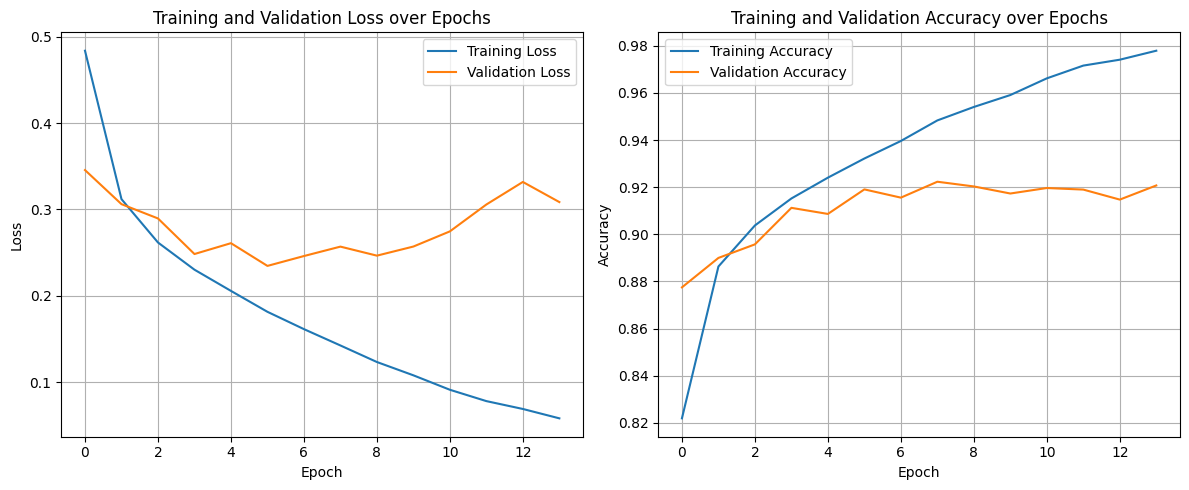

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

**Training and Validation Loss/Accuracy Curves**

The training curves  visually diagnose the model's learning progress:
- Loss Curve: The Training Loss consistently decreases throughout the training process, indicating the model is effectively learning the patterns in the training data. The Validation Loss initially decreases but begins to flatten and rise slightly around Epoch 6 or 7, particularly after the steepest decline.
- Accuracy Curve: The Training Accuracy steadily increases, achieving a high value (over $97\%$) by the end of training. The Validation Accuracy rapidly improves initially, stabilizing around $91-92\%$ after Epoch 6.
- Overfitting Diagnosis: The widening gap between the Training Loss and Validation Loss (and the stagnation/slight drop in Validation Accuracy while Training Accuracy continues to rise) after Epoch 6 or 7 is a classic sign of overfitting. The model is beginning to memorize the noise and specific patterns of the training set, which do not generalize to the unseen validation data. The Early Stopping mechanism successfully halted training when this generalization performance began to degrade significantly, effectively mitigating severe overfitting.

**Learned Filters of Convolutional Layers (Keras)**


--- Visualizing Convolutional Layer Filters ---


/tmp/ipykernel_131/1820891241.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


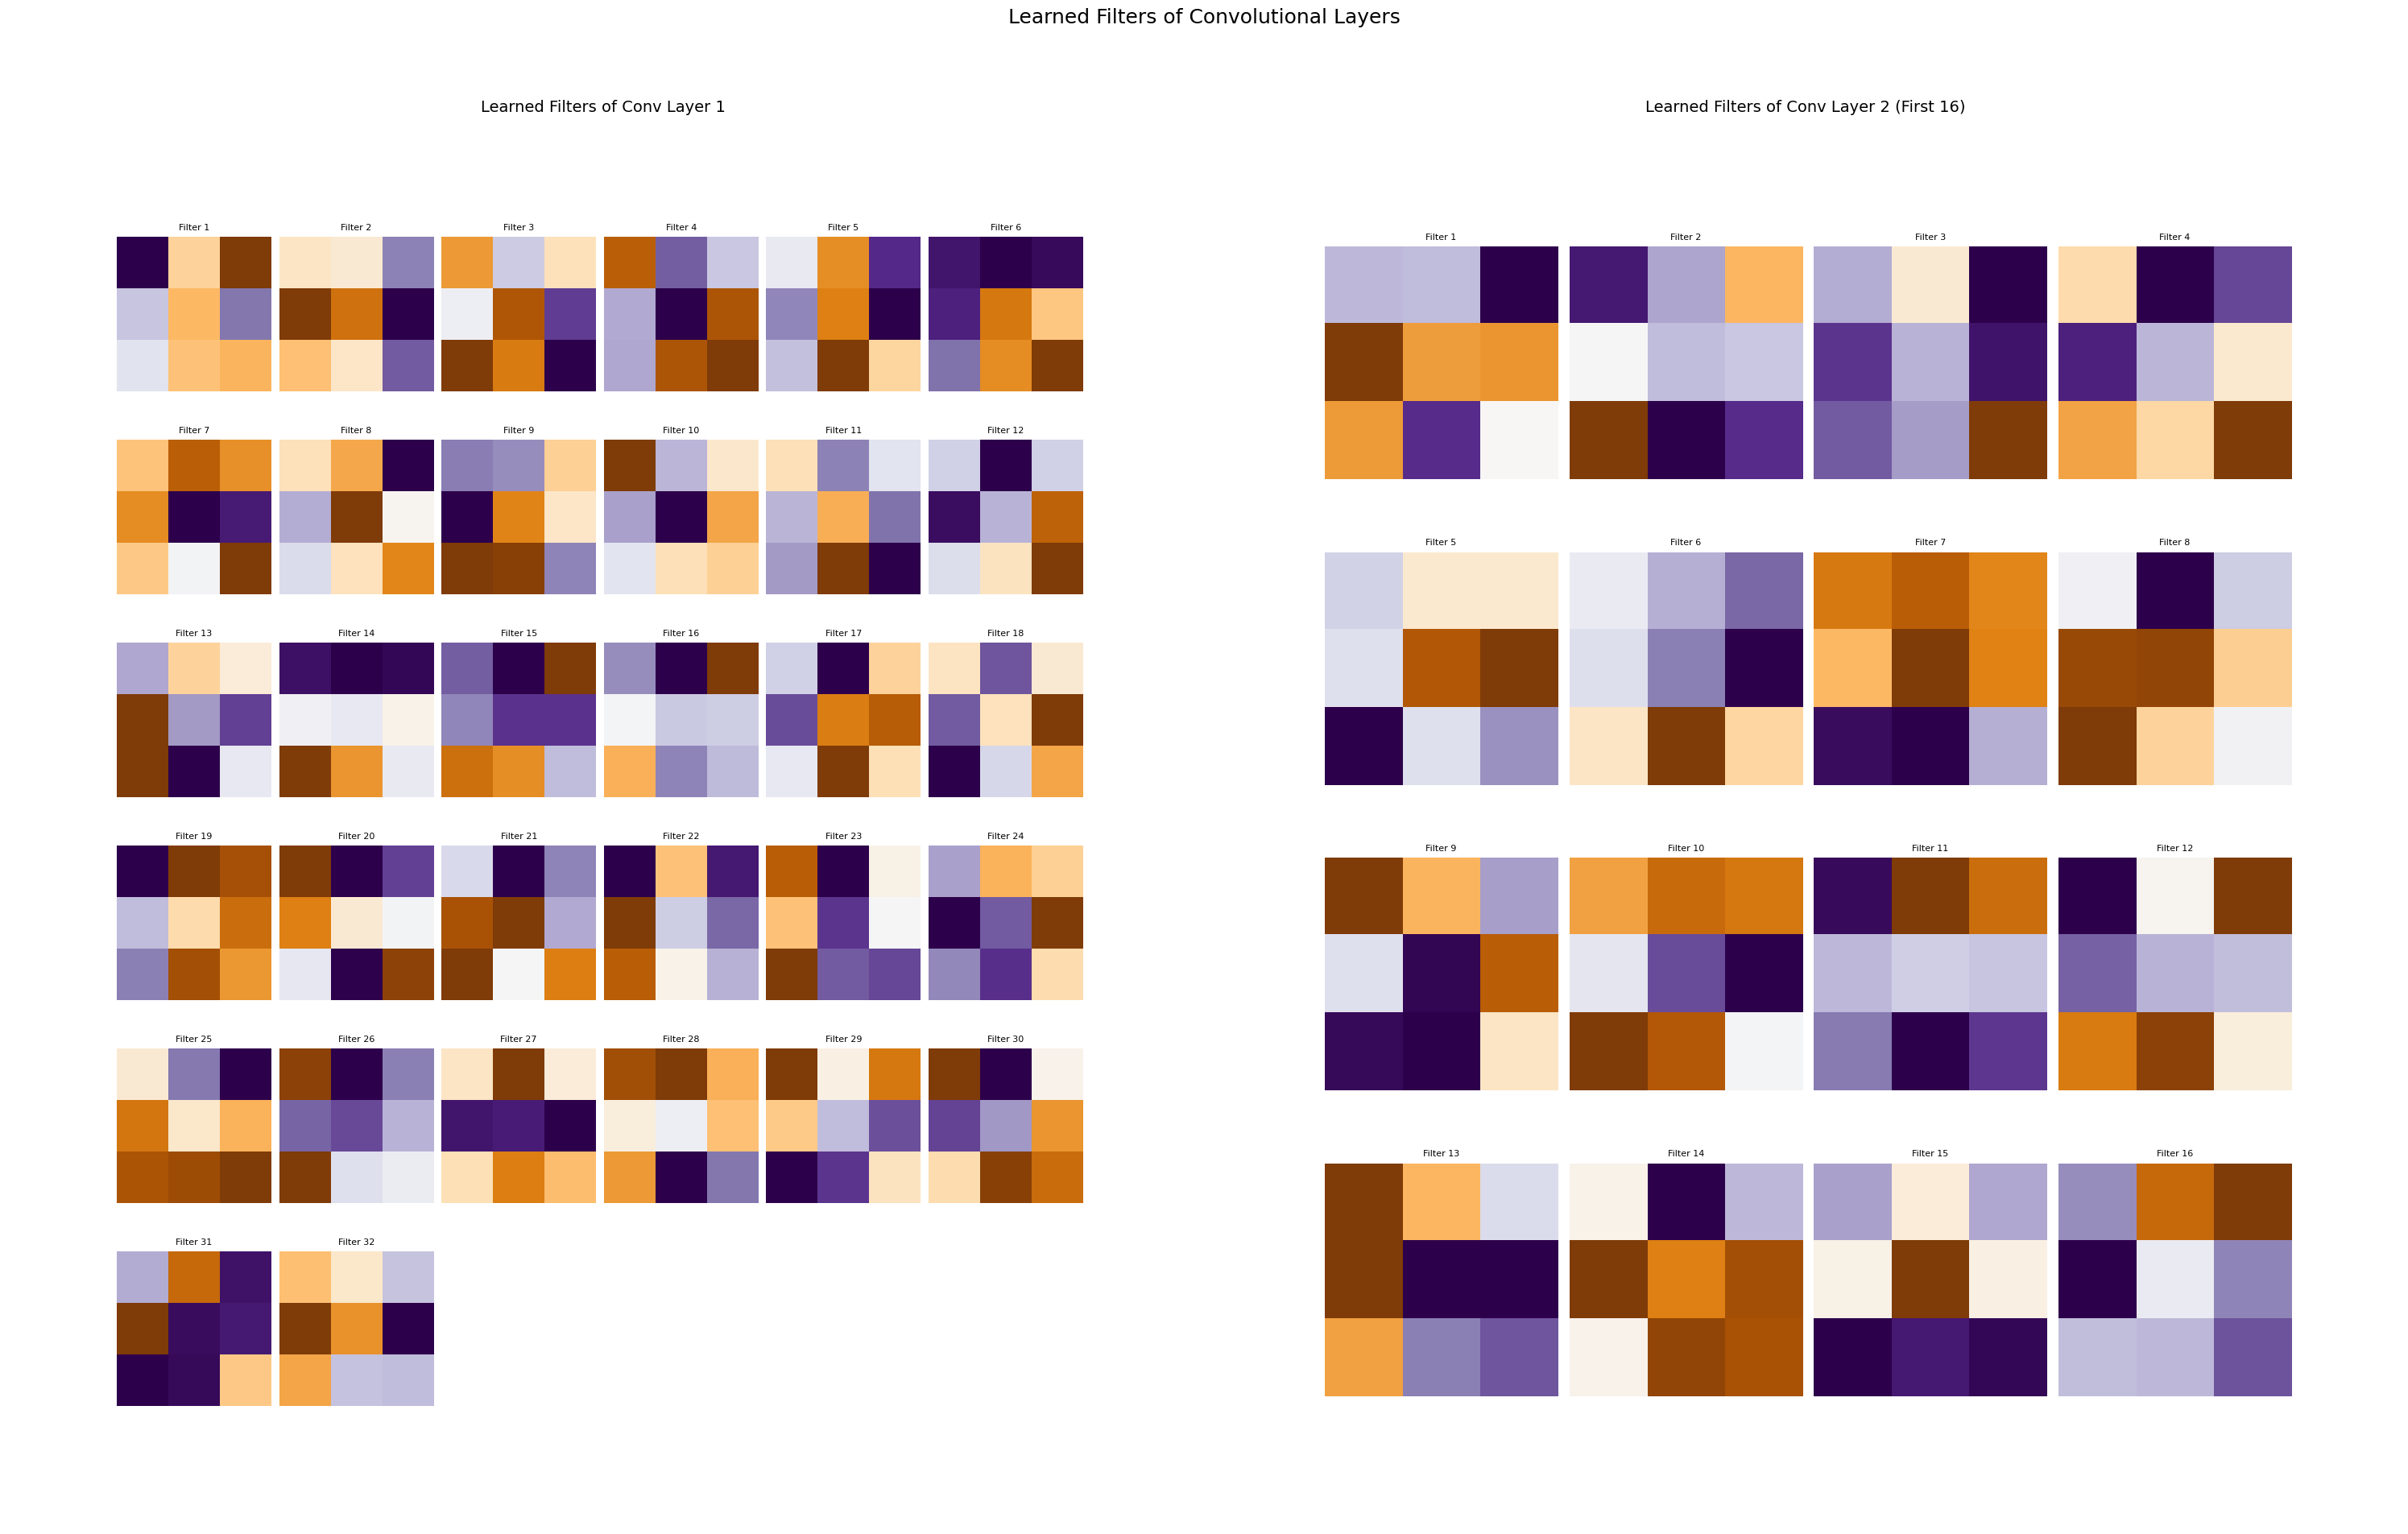

In [ ]:
print("\n--- Visualizing Convolutional Layer Filters ---")

filters_conv1 = model.layers[0].get_weights()[0]
num_filters_conv1 = filters_conv1.shape[-1]

filters_conv2 = model.layers[2].get_weights()[0]
num_filters_conv2 = filters_conv2.shape[-1]

fixed_figsize = (30, 20)

fig, axes = plt.subplots(1, 2, figsize=fixed_figsize)

ax1 = axes[0]
ax1.set_title('Learned Filters of Conv Layer 1', fontsize=14, pad=20)
ax1.axis('off')

grid_cols_conv1 = int(np.ceil(np.sqrt(num_filters_conv1)))
grid_rows_conv1 = int(np.ceil(num_filters_conv1 / grid_cols_conv1))

gs1 = plt.GridSpec(grid_rows_conv1, grid_cols_conv1, figure=fig)
gs1.update(left=0.05, right=0.45, wspace=0.05, hspace=0.05, top=0.85, bottom=0.1)

for i in range(num_filters_conv1):
    ax_filter1 = fig.add_subplot(gs1[i // grid_cols_conv1, i % grid_cols_conv1])
    filter_img = filters_conv1[:, :, 0, i]

    min_val, max_val = filter_img.min(), filter_img.max()
    if max_val - min_val > 1e-6:
        filter_img = (filter_img - min_val) / (max_val - min_val)
    else:
        filter_img = np.zeros_like(filter_img)

    ax_filter1.imshow(filter_img, cmap='PuOr')
    ax_filter1.set_title(f'Filter {i+1}', fontsize=8)
    ax_filter1.axis('off')

ax2 = axes[1]
ax2.set_title('Learned Filters of Conv Layer 2 (First 16)', fontsize=14, pad=20)
ax2.axis('off')

plot_filters_count_conv2 = min(16, num_filters_conv2)
grid_cols_conv2 = int(np.ceil(np.sqrt(plot_filters_count_conv2)))
grid_rows_conv2 = int(np.ceil(plot_filters_count_conv2 / grid_cols_conv2))

gs2 = plt.GridSpec(grid_rows_conv2, grid_cols_conv2, figure=fig)
gs2.update(left=0.55, right=0.95, wspace=0.05, hspace=0.05, top=0.85, bottom=0.1)

for i in range(plot_filters_count_conv2):
    ax_filter2 = fig.add_subplot(gs2[i // grid_cols_conv2, i % grid_cols_conv2])
    filter_img_conv2 = filters_conv2[:, :, :, i].mean(axis=-1)

    min_val, max_val = filter_img_conv2.min(), filter_img_conv2.max()
    if max_val - min_val > 1e-6:
        filter_img_conv2 = (filter_img_conv2 - min_val) / (max_val - min_val)
    else:
        filter_img_conv2 = np.zeros_like(filter_img_conv2)

    ax_filter2.imshow(filter_img_conv2, cmap='PuOr')
    ax_filter2.set_title(f'Filter {i+1}', fontsize=8)
    ax_filter2.axis('off')

fig.suptitle('Learned Filters of Convolutional Layers', fontsize=18, y=0.98)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

**Learned Filters of Convolutional Layers**

The visualization of the learned filters provides a glimpse into the feature representations the CNN has developed:

- Conv Layer 1: The filters learned in the first layer are simple, low-level detectors. They appear as clear patterns of contrasting colors (e.g., dark vs. light halves, diagonals), corresponding to detectors for edges, gradients, and basic textural components. These are the fundamental visual elements the network uses to build more complex features.
- Conv Layer 2: The filters in the second layer are more complex and less interpretable. These filters are not operating directly on the raw pixel data but on the feature maps generated by the first layer. They represent higher-order features—combinations of the basic edges and textures—necessary to recognize small corners, arcs, or repeating patterns that form the components of the garments. The complexity demonstrates the hierarchical nature of CNN feature learning.

**Decision Boundary in Latent Space Visualization (Keras)**


--- Visualizing CNN Decision Boundary using PCA ---
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


/tmp/ipykernel_131/1463580694.py:41: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('viridis', num_classes)


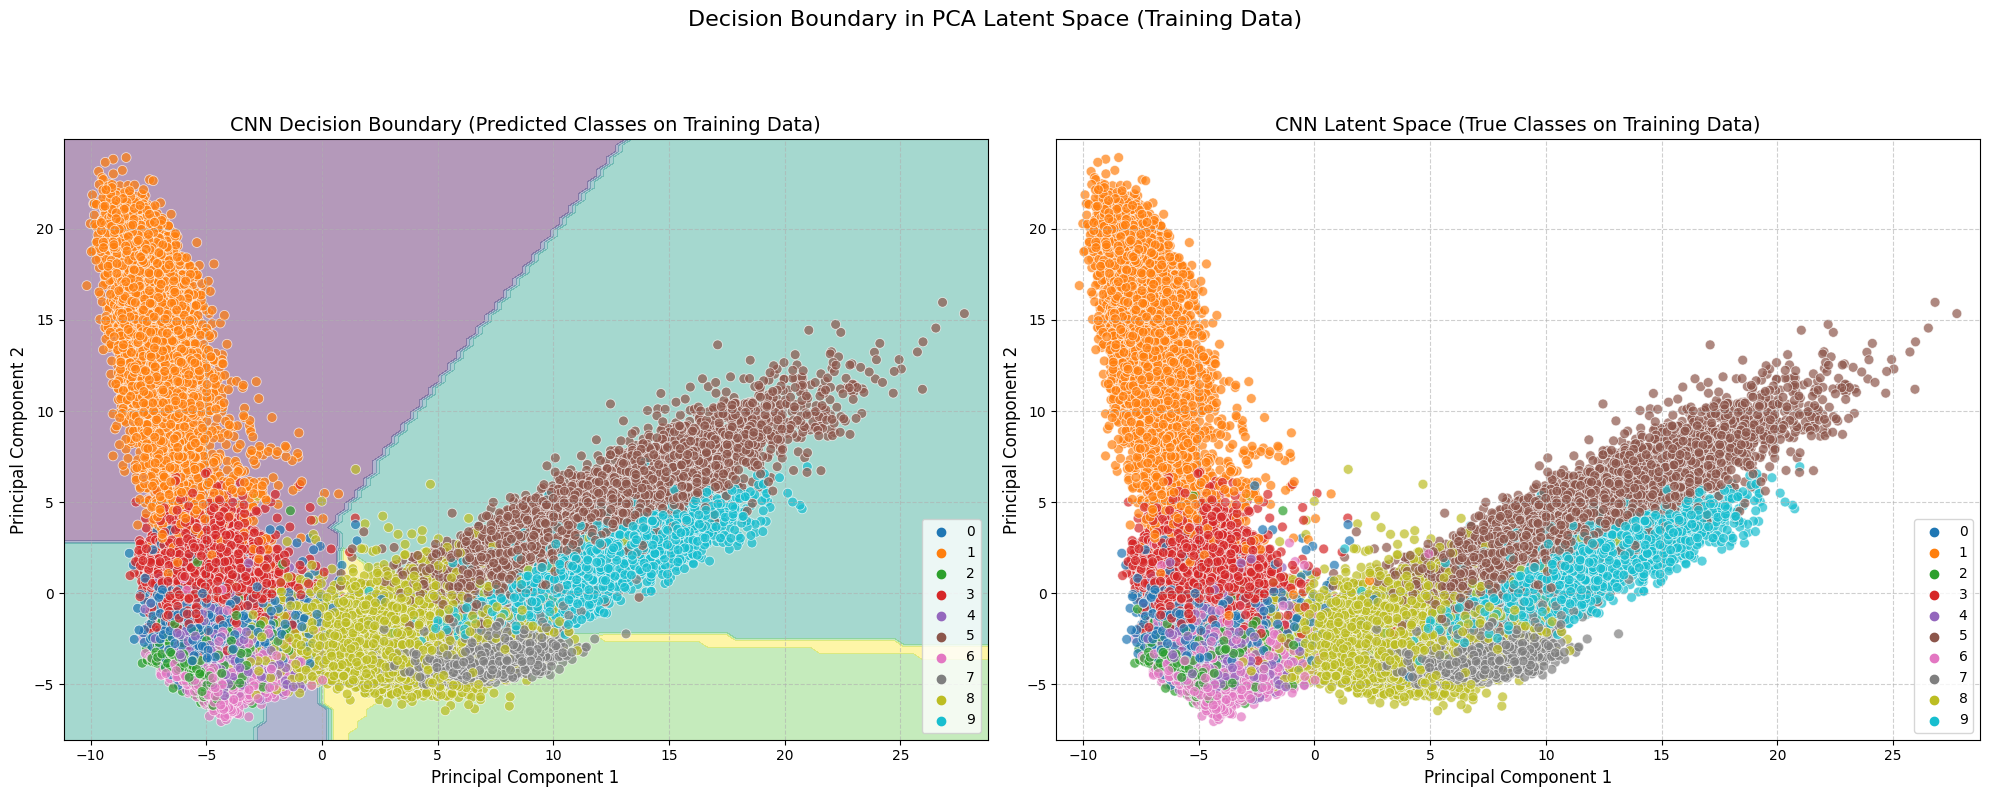

In [ ]:
print("\n--- Visualizing CNN Decision Boundary using PCA ---")

def get_intermediate_model(model, layer_name):
    layer_index = [layer.name for layer in model.layers].index(layer_name)
    intermediate_model = Sequential(model.layers[:layer_index + 1])
    return intermediate_model

intermediate_model = get_intermediate_model(model, 'fc_intermediate')
intermediate_features = intermediate_model.predict(x_train_cnn, batch_size=64)

pca = PCA(n_components=2)
pca_features = pca.fit_transform(intermediate_features)

predicted_labels = np.argmax(model.predict(x_train_cnn, batch_size=64), axis=1)

x_min, x_max = pca_features[:, 0].min() - 1, pca_features[:, 0].max() + 1
y_min, y_max = pca_features[:, 1].min() - 1, pca_features[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
meshgrid_points = np.c_[xx.ravel(), yy.ravel()]

reconstructed_features = pca.inverse_transform(meshgrid_points)

layer_index = [layer.name for layer in model.layers].index('fc_intermediate')
sub_model = Sequential(model.layers[layer_index + 1:])

Z_proba = sub_model.predict(reconstructed_features, batch_size=64)
Z = np.argmax(Z_proba, axis=1).reshape(xx.shape)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
cmap = plt.cm.get_cmap('viridis', num_classes)

contourf_plot = ax1.contourf(xx, yy, Z, alpha=0.4, cmap=cmap)
sns.scatterplot(
    x=pca_features[:, 0],
    y=pca_features[:, 1],
    hue=predicted_labels,
    palette=sns.color_palette("tab10", n_colors=num_classes),
    legend='full',
    alpha=0.7,
    s=50,
    ax=ax1
)
ax1.set_title('CNN Decision Boundary (Predicted Classes on Training Data)', fontsize=14)
ax1.set_xlabel('Principal Component 1', fontsize=12)
ax1.set_ylabel('Principal Component 2', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.set_xlim(xx.min(), xx.max())
ax1.set_ylim(yy.min(), yy.max())

sns.scatterplot(
    x=pca_features[:, 0],
    y=pca_features[:, 1],
    hue=y_train_keras,
    palette=sns.color_palette("tab10", n_colors=num_classes),
    legend='full',
    alpha=0.7,
    s=50,
    ax=ax2
)
ax2.set_title('CNN Latent Space (True Classes on Training Data)', fontsize=14)
ax2.set_xlabel('Principal Component 1', fontsize=12)
ax2.set_ylabel('Principal Component 2', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.set_xlim(xx.min(), xx.max())
ax2.set_ylim(yy.min(), yy.max())

fig.suptitle('Decision Boundary in PCA Latent Space (Training Data)', fontsize=16, y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

**Decision Boundary in PCA Latent Space**

The decision boundary visualization maps the high-dimensional feature space learned by the CNN into a simplified 2D space using Principal Component Analysis (PCA) for interpretability.

- Latent Space Clustering (Right Plot): The plot of the True Classes shows that the CNN successfully transformed the raw image data into a latent space where data points belonging to the same class are significantly clustered together. This confirms the network's ability to learn semantically meaningful representations. Notably, classes that are visually similar (e.g., 'T-shirt/top', 'Pullover', 'Shirt') may show some overlap, while distinct categories (like 'Trouser' or 'Bag') are clearly separated.
- Decision Boundaries (Left Plot): The predicted classes plot shows the boundaries established by the final Softmax layer. The colored regions represent the areas where the model predicts a specific class. The boundaries are generally smooth and effectively separate the main clusters, but areas of overlap and the resulting complex boundaries around the cluster interfaces (where confusion is highest) indicate where the model makes mistakes. The clear separation of the clusters validates the high accuracy achieved by the model on this task.

## Model Architecture, Model Building (TensorFlow custom function), and Model Training

This section details the construction and training of a Convolutional Neural Network (CNN) incorporating custom layer implementation and a custom activation function, followed by an interpretation of the training results and a distinction between the underlying frameworks.

**Custom Component and Implementation**

The model demonstrates advanced design patterns by implementing proprietary components using TensorFlow's low-level APIs.

1. Custom Activation Function: Leaky ReLU

The `custom_leaky_relu` function introduces a non-linear transformation that is crucial for a neural network's ability to model complex, non-linear relationships in data.
- Purpose: It serves as a more robust alternative to the standard ReLU activation.
- Theoretical Principle: The function is defined as $\text{Leaky ReLU}(x) = \max(x, \alpha x)$, with a small positive slope ($\alpha=0.2$) for negative inputs. This ensures a non-zero gradient flows even when the pre-activation value is negative, successfully addressing the Dying ReLU problem where neurons can become permanently inactive during training. The use of the @tf.function decorator compiles the Python function into a high-performance TensorFlow graph, optimizing execution speed.

2. Custom Dense Layer Implementation

The `CustomDenseLayer` class, defined by subclassing `tf.keras.layers.Layer`, provides granular control over the layer's operation and parameters.
- The build Method: This method is the parameter initialization stage. It creates the layer's trainable state: the weight matrix ($\mathbf{w}$) and the bias vector ($\mathbf{b}$). The $\mathbf{glorot_uniform}$ initializer is utilized to set initial weights, a heuristic that helps ensure the variance of the layer's inputs and outputs remains consistent, contributing to stable training.
- The call Method: This defines the forward pass. It executes the core neural network operation, a linear transformation ($\mathbf{XW} + \mathbf{b}$), followed by the application of the specified activation function.

**Model Architecture and Training**

The CNN structure follows a common hierarchical design: two convolutional blocks ($\text{Conv2D} \rightarrow \text{MaxPooling2D}$) for feature extraction, followed by a $\text{Flatten}$ layer and dense classification layers.
- Key Customization: The intermediate fully connected layer uses the CustomDenseLayer paired with the `custom_leaky_relu` activation.
- Optimization and Loss: The model is compiled using the Adam optimizer and $\mathbf{Sparse\ Categorical\ Cross-Entropy}$ loss, which is suitable for integer-encoded labels.
- Regularization: $\mathbf{Early\ Stopping}$ is used as a regularization technique. By monitoring the $\mathbf{validation\ loss}$ and stopping training when no improvement is observed for a set patience (8 epochs), the training process minimizes the risk of overfitting and restores the weights corresponding to the best generalization performance.

In [ ]:
@tf.function
def custom_leaky_relu(x, alpha=0.2):
    return tf.maximum(x, alpha * x)

class CustomDenseLayer(tf.keras.layers.Layer):
    def __init__(self, units, activation=None, name=None, **kwargs):
        super(CustomDenseLayer, self).__init__(name=name, **kwargs)
        self.units = units
        self.activation = tf.keras.activations.get(activation)

    def build(self, input_shape):
        self.w = self.add_weight(
            name='kernel',
            shape=(input_shape[-1], self.units),
            initializer='glorot_uniform',
            trainable=True,
        )
        self.b = self.add_weight(
            name='bias',
            shape=(self.units,),
            initializer='zeros',
            trainable=True,
        )
        super(CustomDenseLayer, self).build(input_shape)

    def call(self, inputs):
        output = tf.matmul(inputs, self.w) + self.b
        if self.activation is not None:
            output = self.activation(output)
        return output

    def get_config(self):
        config = super(CustomDenseLayer, self).get_config()
        config.update({
            "units": self.units,
            "activation": tf.keras.activations.serialize(self.activation),
        })
        return config

num_classes = len(np.unique(y_train_keras))

model = Sequential([
    Input(shape=(28, 28, 1)),
    tf.keras.layers.Conv2D(32, kernel_size=(3, 3), padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),
    tf.keras.layers.Conv2D(64, kernel_size=(3, 3), padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),
    Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    CustomDenseLayer(64, activation=custom_leaky_relu, name='fc_intermediate_custom'),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

print("\n--- Keras CNN Model Architecture ---")
model.summary()
print("="*40 + "\n")

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

num_epochs = 100
batch_size = 64
validation_split = 0.2

print("--- Starting Training ---")
history = model.fit(
    x_train_cnn, y_train_keras,
    epochs=num_epochs,
    batch_size=batch_size,
    validation_split=validation_split,
    callbacks=[early_stopping],
    verbose=1
)
print("\n--- Training Complete ---")
print("="*40 + "\n")


--- Keras CNN Model Architecture ---


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_intermediate_custom          │ (None, 64)             │         8,256 │
│ (CustomDenseLayer)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 429,258 (1.64 MB)

 Trainable params: 429,258 (1.64 MB)

 Non-trainable params: 0 (0.00 B)


--- Starting Training ---
Epoch 1/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.7578 - loss: 0.6599 - val_accuracy: 0.8785 - val_loss: 0.3435
Epoch 2/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8884 - loss: 0.3114 - val_accuracy: 0.9000 - val_loss: 0.2796
Epoch 3/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9062 - loss: 0.2580 - val_accuracy: 0.9034 - val_loss: 0.2722
Epoch 4/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9172 - loss: 0.2232 - val_accuracy: 0.9082 - val_loss: 0.2527
Epoch 5/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9282 - loss: 0.1906 - val_accuracy: 0.9067 - val_loss: 0.2607
Epoch 6/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9394 - loss: 0.1644 - val_accuracy: 0.9147 - val_loss: 0.2375
Epoch 7/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9455 - loss: 0.1493 - val_accuracy: 0.9171 - val_loss: 0.2396
Epoch 8/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.952

**Model Training History**

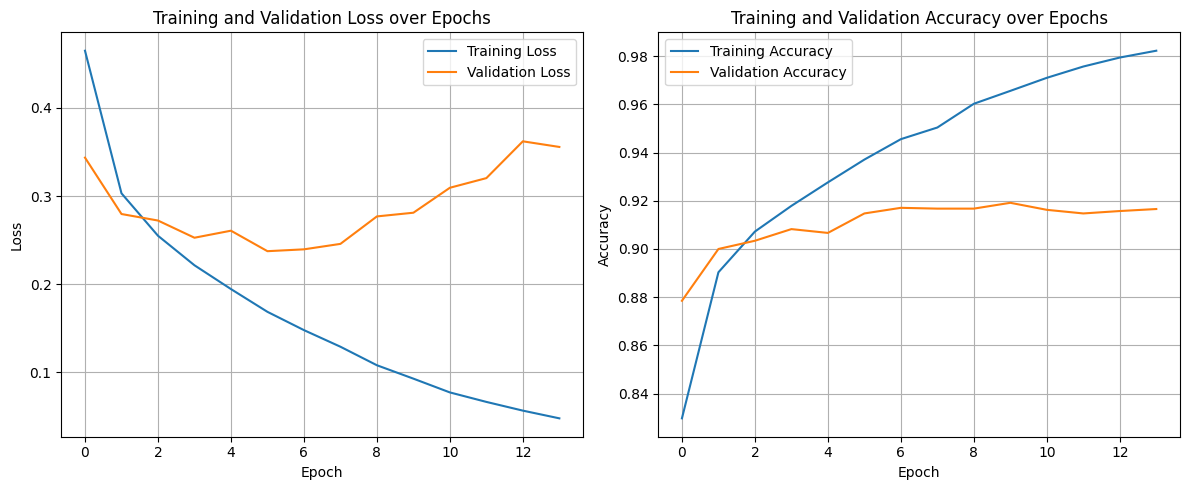

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss') 
plt.plot(history.history['val_loss'], label='Validation Loss') 
plt.title('Training and Validation Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy') 
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

**Training and Validation Loss/Accuracy Curves**

The learning curves reveal the network's behavior over 14 epochs:
- Training Progress: The Training Loss steadily and rapidly decreases, while the Training Accuracy climbs towards $\mathbf{98\%}$. This indicates the model is highly effective at minimizing error on the data it has seen.
- Generalization: The Validation Loss decreases sharply initially but then stabilizes and begins to increase from Epoch 6 onward, while Validation Accuracy peaks around $\mathbf{91.9\%}$ and then stabilizes.
- Overfitting: The noticeable and widening gap between the continuously decreasing Training Loss and the increasing Validation Loss after Epoch 6 is a strong sign of overfitting. The model starts memorizing the specifics and noise of the training data that are not representative of the broader problem space. The Early Stopping mechanism, triggered by the lack of improvement in validation loss, correctly halted the training process.

**Learned Filters of Convolutional Layers (TensoFlow custom layer)**


--- Visualizing Convolutional Layer Filters ---


/tmp/ipykernel_131/1820891241.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


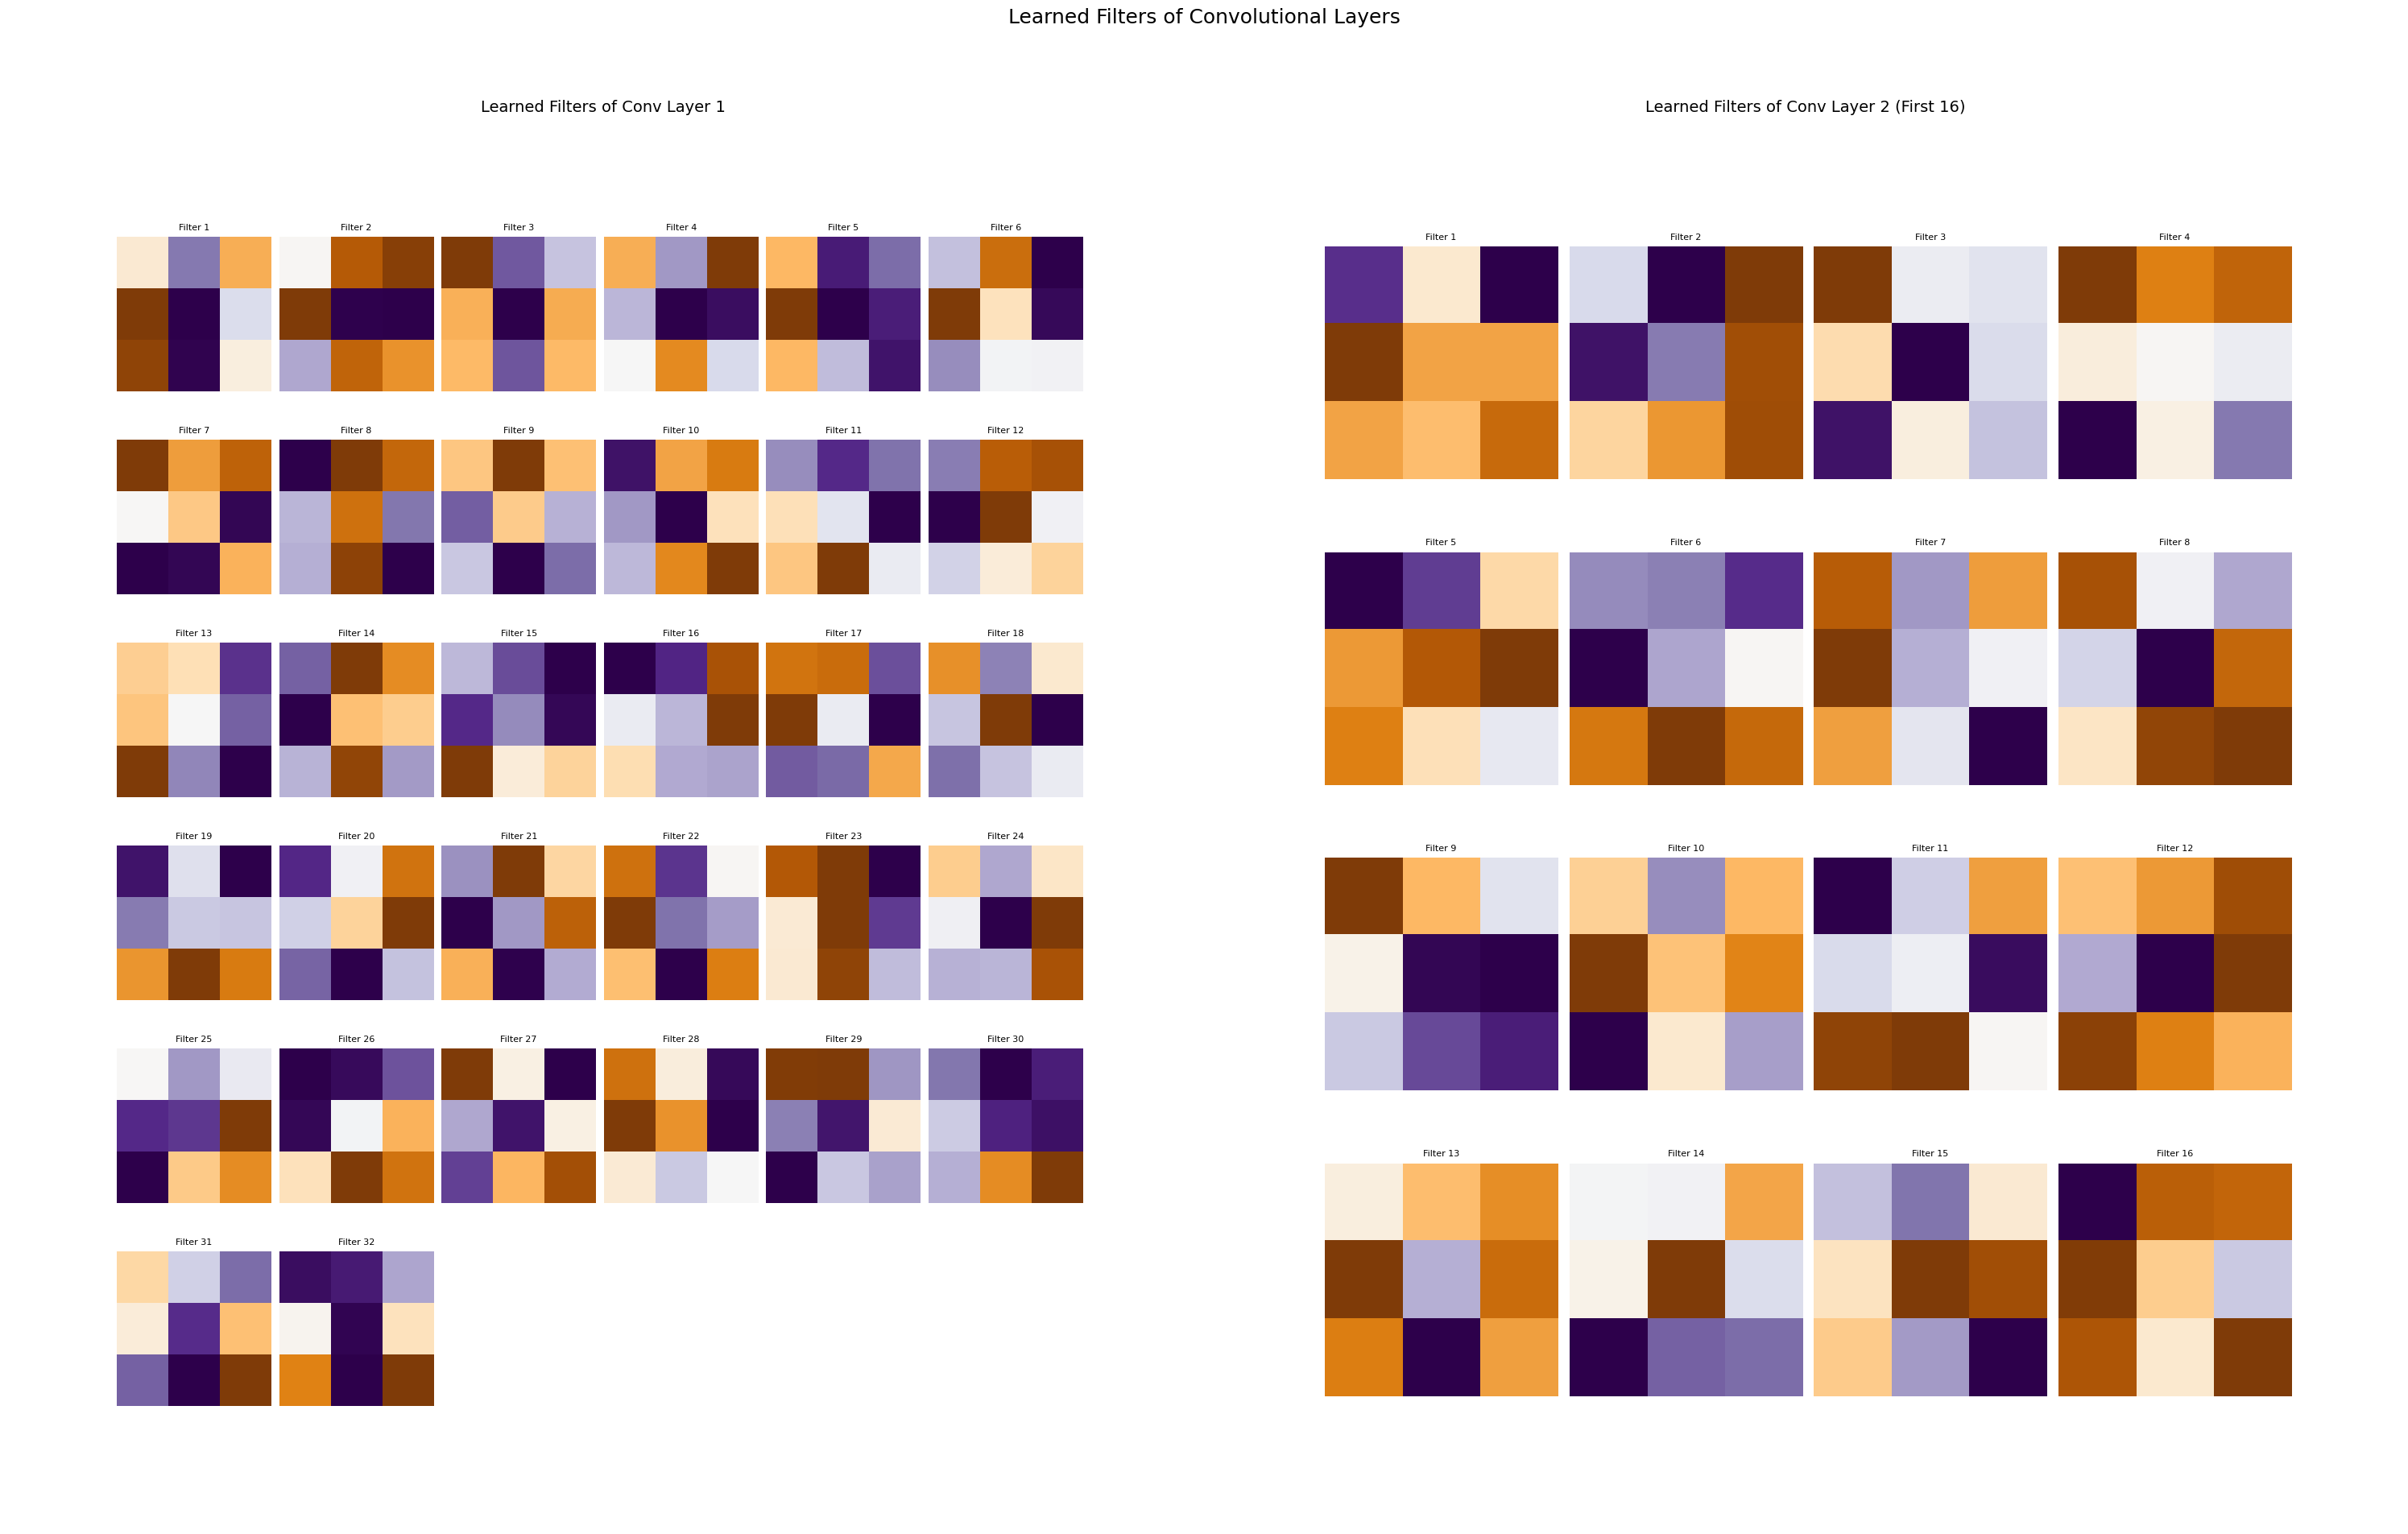

In [ ]:
print("\n--- Visualizing Convolutional Layer Filters ---")

filters_conv1 = model.layers[0].get_weights()[0]
num_filters_conv1 = filters_conv1.shape[-1]

filters_conv2 = model.layers[2].get_weights()[0]
num_filters_conv2 = filters_conv2.shape[-1]

fixed_figsize = (30, 20)

fig, axes = plt.subplots(1, 2, figsize=fixed_figsize)

ax1 = axes[0]
ax1.set_title('Learned Filters of Conv Layer 1', fontsize=14, pad=20)
ax1.axis('off')

grid_cols_conv1 = int(np.ceil(np.sqrt(num_filters_conv1)))
grid_rows_conv1 = int(np.ceil(num_filters_conv1 / grid_cols_conv1))

gs1 = plt.GridSpec(grid_rows_conv1, grid_cols_conv1, figure=fig)
gs1.update(left=0.05, right=0.45, wspace=0.05, hspace=0.05, top=0.85, bottom=0.1)

for i in range(num_filters_conv1):
    ax_filter1 = fig.add_subplot(gs1[i // grid_cols_conv1, i % grid_cols_conv1])
    filter_img = filters_conv1[:, :, 0, i]

    min_val, max_val = filter_img.min(), filter_img.max()
    if max_val - min_val > 1e-6:
        filter_img = (filter_img - min_val) / (max_val - min_val)
    else:
        filter_img = np.zeros_like(filter_img)

    ax_filter1.imshow(filter_img, cmap='PuOr')
    ax_filter1.set_title(f'Filter {i+1}', fontsize=8)
    ax_filter1.axis('off')

ax2 = axes[1]
ax2.set_title('Learned Filters of Conv Layer 2 (First 16)', fontsize=14, pad=20)
ax2.axis('off')

plot_filters_count_conv2 = min(16, num_filters_conv2)
grid_cols_conv2 = int(np.ceil(np.sqrt(plot_filters_count_conv2)))
grid_rows_conv2 = int(np.ceil(plot_filters_count_conv2 / grid_cols_conv2))

gs2 = plt.GridSpec(grid_rows_conv2, grid_cols_conv2, figure=fig)
gs2.update(left=0.55, right=0.95, wspace=0.05, hspace=0.05, top=0.85, bottom=0.1)

for i in range(plot_filters_count_conv2):
    ax_filter2 = fig.add_subplot(gs2[i // grid_cols_conv2, i % grid_cols_conv2])
    filter_img_conv2 = filters_conv2[:, :, :, i].mean(axis=-1)

    min_val, max_val = filter_img_conv2.min(), filter_img_conv2.max()
    if max_val - min_val > 1e-6:
        filter_img_conv2 = (filter_img_conv2 - min_val) / (max_val - min_val)
    else:
        filter_img_conv2 = np.zeros_like(filter_img_conv2)

    ax_filter2.imshow(filter_img_conv2, cmap='PuOr')
    ax_filter2.set_title(f'Filter {i+1}', fontsize=8)
    ax_filter2.axis('off')

fig.suptitle('Learned Filters of Convolutional Layers', fontsize=18, y=0.98)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

The filter visualizations illustrate the features the network has learned:

- Conv Layer 1: The filters are primarily low-level detectors for simple edges and color gradients (as represented by the purple/orange contrast). These are the building blocks of visual recognition.
- Conv Layer 2: These filters exhibit more complex, abstract patterns. They act as high-level feature detectors, combining the basic edges from the first layer to recognize corners, curves, and textures that comprise the final garment images.

**Decision Boundary in Latent Space Visualization (TensoFlow custom function)**


--- Visualizing CNN Decision Boundary using PCA ---
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


/tmp/ipykernel_131/2511990402.py:41: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('viridis', num_classes)


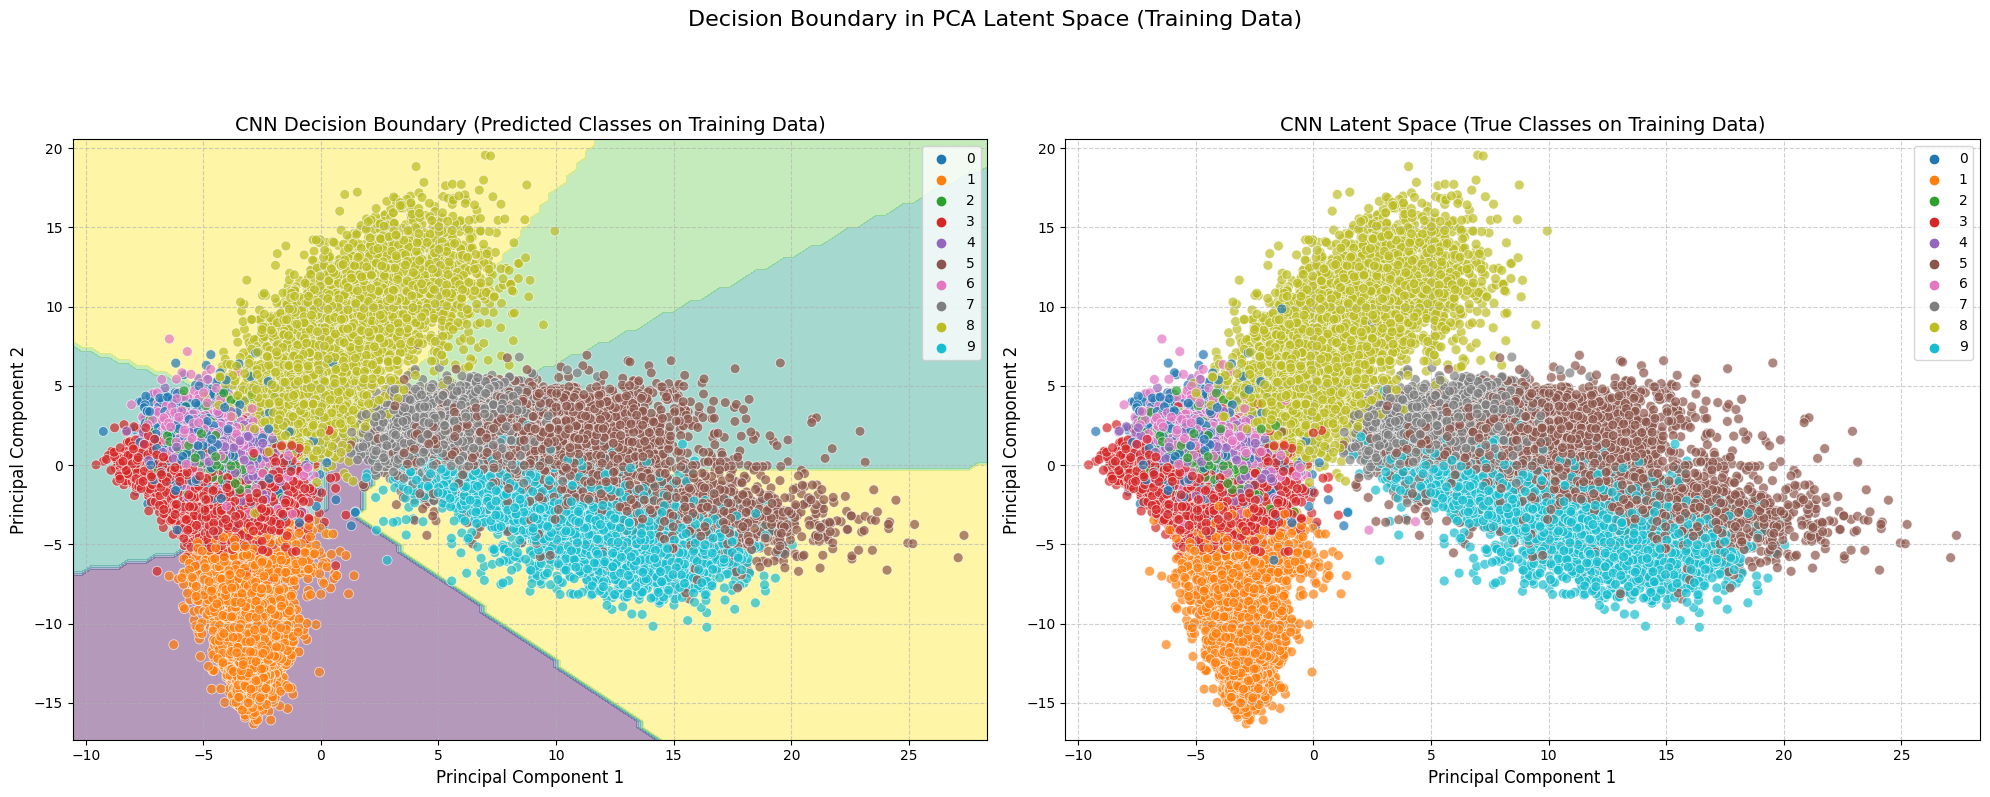

In [ ]:
print("\n--- Visualizing CNN Decision Boundary using PCA ---")

def get_intermediate_model(model, layer_name):
    layer_index = [layer.name for layer in model.layers].index(layer_name)
    intermediate_model = Sequential(model.layers[:layer_index + 1])
    return intermediate_model

intermediate_model = get_intermediate_model(model, 'fc_intermediate_custom')
intermediate_features = intermediate_model.predict(x_train_cnn, batch_size=64)

pca = PCA(n_components=2)
pca_features = pca.fit_transform(intermediate_features)

predicted_labels = np.argmax(model.predict(x_train_cnn, batch_size=64), axis=1)

x_min, x_max = pca_features[:, 0].min() - 1, pca_features[:, 0].max() + 1
y_min, y_max = pca_features[:, 1].min() - 1, pca_features[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
meshgrid_points = np.c_[xx.ravel(), yy.ravel()]

reconstructed_features = pca.inverse_transform(meshgrid_points)

layer_index = [layer.name for layer in model.layers].index('fc_intermediate_custom')
sub_model = Sequential(model.layers[layer_index + 1:])

Z_proba = sub_model.predict(reconstructed_features, batch_size=64)
Z = np.argmax(Z_proba, axis=1).reshape(xx.shape)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
cmap = plt.cm.get_cmap('viridis', num_classes)

contourf_plot = ax1.contourf(xx, yy, Z, alpha=0.4, cmap=cmap)
sns.scatterplot(
    x=pca_features[:, 0],
    y=pca_features[:, 1],
    hue=predicted_labels,
    palette=sns.color_palette("tab10", n_colors=num_classes),
    legend='full',
    alpha=0.7,
    s=50,
    ax=ax1
)
ax1.set_title('CNN Decision Boundary (Predicted Classes on Training Data)', fontsize=14)
ax1.set_xlabel('Principal Component 1', fontsize=12)
ax1.set_ylabel('Principal Component 2', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.set_xlim(xx.min(), xx.max())
ax1.set_ylim(yy.min(), yy.max())

sns.scatterplot(
    x=pca_features[:, 0],
    y=pca_features[:, 1],
    hue=y_train_keras,
    palette=sns.color_palette("tab10", n_colors=num_classes),
    legend='full',
    alpha=0.7,
    s=50,
    ax=ax2
)
ax2.set_title('CNN Latent Space (True Classes on Training Data)', fontsize=14)
ax2.set_xlabel('Principal Component 1', fontsize=12)
ax2.set_ylabel('Principal Component 2', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.set_xlim(xx.min(), xx.max())
ax2.set_ylim(yy.min(), yy.max())

fig.suptitle('Decision Boundary in PCA Latent Space (Training Data)', fontsize=16, y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

The decision boundary visualization shows the separability of the classes in the space transformed by the custom intermediate dense layer.

- Latent Space Clustering (Right Plot): The true classes are projected onto the 2D plane by PCA. The classes form distinct, well-separated clusters. This demonstrates that the CNN's feature extraction layers, including the custom dense layer, successfully map the images into a latent space where class identity is highly discriminative.
- Decision Boundaries (Left Plot): The boundary lines are smooth and effectively partition the latent space to correspond with the class clusters. The high classification accuracy is visually confirmed by the strong alignment between the predicted regions and the true clusters.

**Keras vs. TensorFlow**

The primary difference between $\mathbf{Keras}$ and $\mathbf{TensorFlow}$ lies in their level of abstraction and user focus.
- TensorFlow (The Platform): TensorFlow is the foundational numerical computation library and the core deep learning framework. It provides low-level tools for defining and executing computational graphs, managing variables, and controlling the underlying hardware (e.g., CPUs, GPUs). Working directly with raw TensorFlow involves manual management of tensors, gradients, and sessions, offering maximum flexibility and control for advanced research or custom low-level operations.
- Keras (The API): Keras is a high-level API designed for fast experimentation and ease of use. It is now the official high-level interface for TensorFlow. Keras abstracts away much of the complexity of raw TensorFlow, providing intuitive, object-oriented APIs (like Sequential models and predefined Layers) that make common tasks like model building, training, and evaluation much simpler and more accessible.
- Relationship: Keras acts as a user-friendly wrapper built on top of the powerful, low-level engine of TensorFlow. The current code explicitly leverages both: Keras for the overall model flow and high-level layers (tf.keras.layers.Conv2D), and raw TensorFlow concepts (like `tf.function and tf.keras.layers.Layer`) for defining custom components.

# Model Evaluation

The final phase involves evaluating the trained Convolutional Neural Network (CNN) on the independent test dataset to assess its generalization capability and analyze its performance across individual classes.

**Evaluation on Test Dataset**

In [ ]:
print("\n--- Evaluation on Test Dataset ---")

loss, accuracy = model.evaluate(x_test_cnn, y_test_keras, verbose=0)
print(f'Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}')


--- Final Evaluation on Test Set and Performance Metrics ---
Test Loss: 0.2227, Test Accuracy: 0.9174


The model's final performance is measured using the unseen test data. The Test Loss represents the model's error, and the Test Accuracy indicates the proportion of correctly classified examples.
- Test Loss: $\mathbf{0.2227}$
- Test Accuracy: $\mathbf{0.9174}$

This test accuracy of approximately $\mathbf{91.7\%}$ confirms that the model successfully generalized the learned features from the training set to new, unseen data, maintaining a high level of classification performance. The final test accuracy is very close to the peak validation accuracy achieved during training, suggesting the Early Stopping mechanism successfully prevented significant degradation from overfitting.

**Classification reports**

A comprehensive set of metrics is calculated to provide a detailed view of the model's predictive power. The Classification Report reveals variations in performance across the 10 Fashion-MNIST classes (refer to for class names).

In [ ]:
y_pred_proba_test_keras = model.predict(x_test_cnn)
y_pred_test_keras = np.argmax(y_pred_proba_test_keras, axis=1)

cm = confusion_matrix(y_test_keras, y_pred_test_keras)
accuracy_final = accuracy_score(y_test_keras, y_pred_test_keras)
precision = precision_score(y_test_keras, y_pred_test_keras, average='macro', zero_division=1)
recall = recall_score(y_test_keras, y_pred_test_keras, average='macro', zero_division=1)
f1 = f1_score(y_test_keras, y_pred_test_keras, average='macro', zero_division=1)

roc_auc_val = roc_auc_score(y_test_keras, y_pred_proba_test_keras, multi_class='ovr')

print(f"Accuracy: {accuracy_final:.3f}")
print(f"Precision (macro): {precision:.3f}")
print(f"Recall (macro): {recall:.3f}")
print(f"F1-score (macro): {f1:.3f}")
print(f"AUC-ROC (OvR): {roc_auc_val:.3f}")

print("\nClassification Report:")
print(classification_report(y_test_keras, y_pred_test_keras, zero_division=1))
print("="*40 + "\n")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Accuracy: 0.917
Precision (macro): 0.919
Recall (macro): 0.917
F1-score (macro): 0.917
AUC-ROC (OvR): 0.995

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1000
           1       1.00      0.98      0.99      1000
           2       0.93      0.79      0.86      1000
           3       0.91      0.95      0.93      1000
           4       0.84      0.90      0.87      1000
           5       0.98      0.98      0.98      1000
           6       0.78      0.76      0.77      1000
           7       0.95      0.96      0.96      1000
           8       0.99      0.98      0.99      1000
           9       0.96      0.96      0.96      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000




**Classification Report Summary**

The model achieved strong overall macro-averaged scores:
- Accuracy: $\mathbf{0.917}$
- Precision (macro): $\mathbf{0.919}$
- Recall (macro): $\mathbf{0.917}$
- F1-score (macro): $\mathbf{0.917}$
- AUC-ROC (OvR): $\mathbf{0.995}$ (One-vs-Rest Area Under the Receiver Operating Characteristic Curve)

The high AUC-ROC value ($\mathbf{0.995}$) indicates excellent separability between the classes; the model is highly capable of assigning a higher probability score to the correct class than to incorrect classes.

**Confusion metrics**

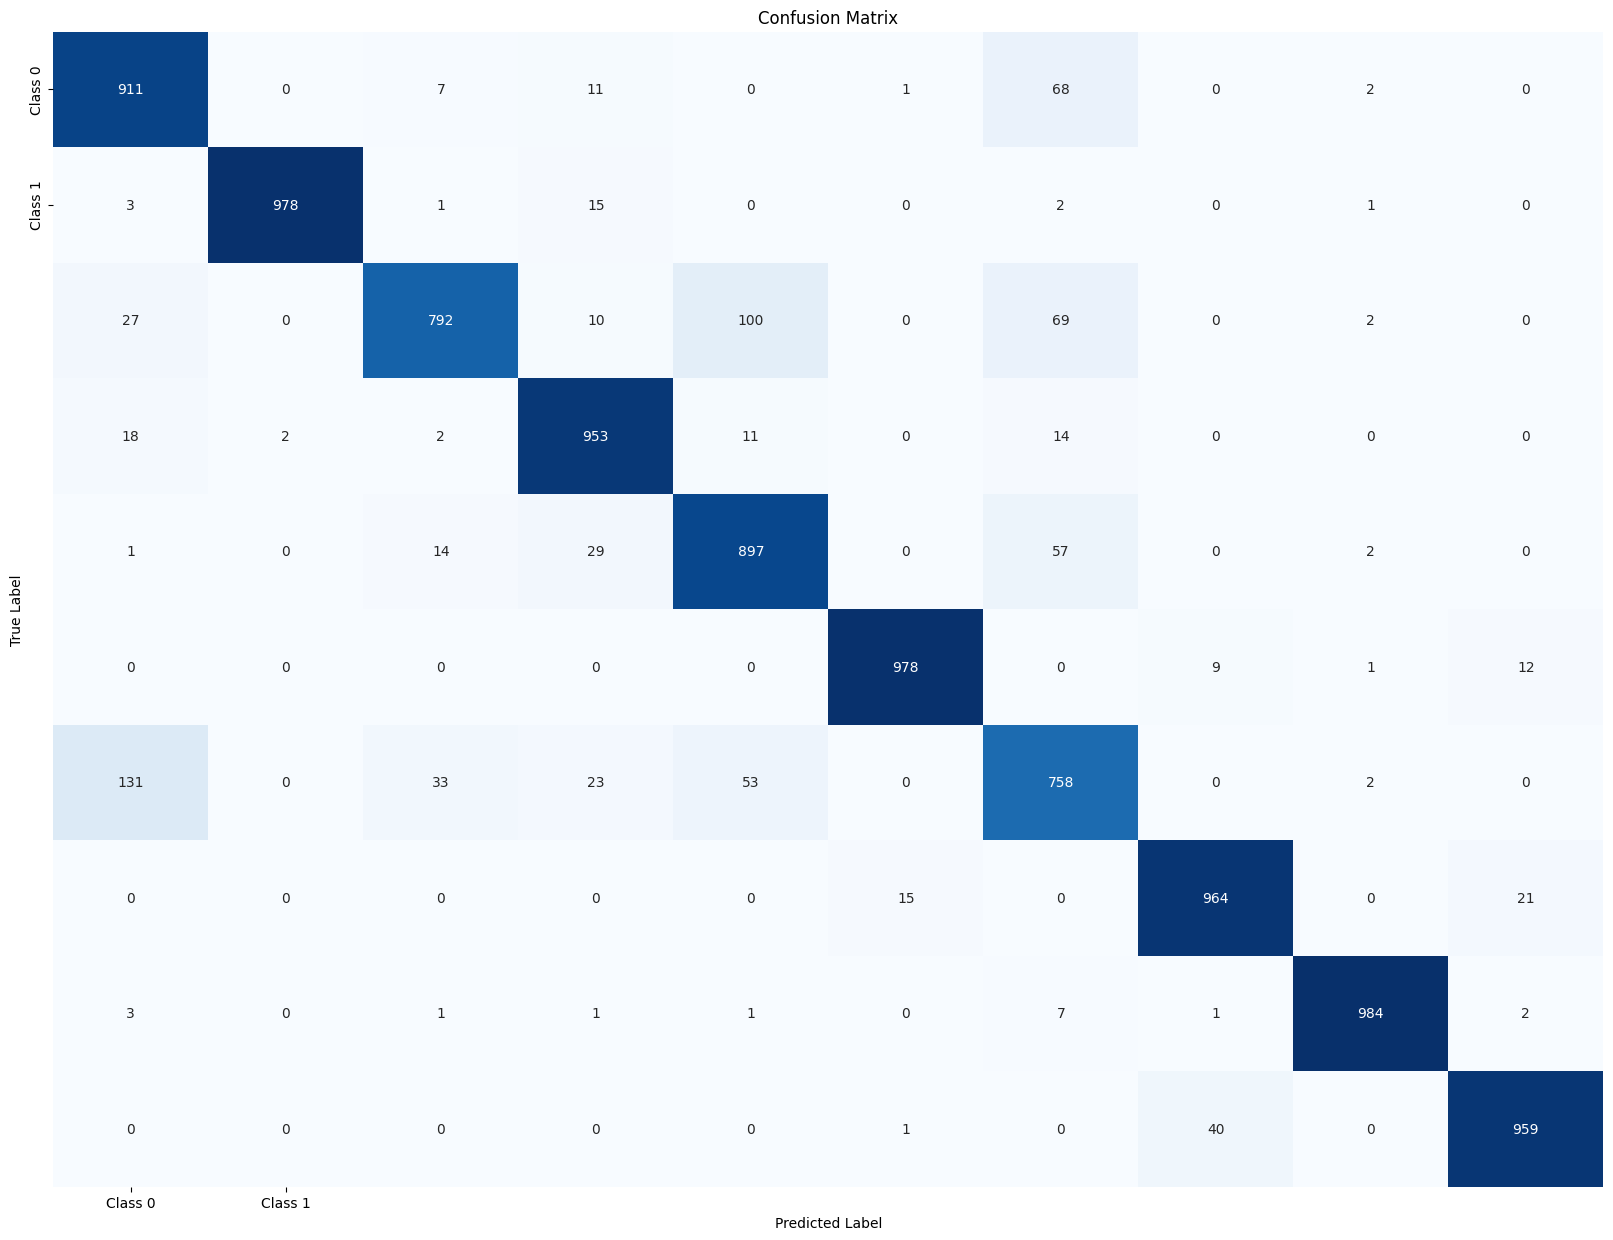

In [ ]:
plt.figure(figsize=(20, 15))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

**Confusion Matrix Insights**

The Confusion Matrix visually highlights misclassifications:
- The large off-diagonal value ($\mathbf{131}$) in row 6, column 0, indicates that $\mathbf{131}$ actual Shirts (Class 6) were incorrectly predicted as T-shirts/tops (Class 0).
- Similarly, $\mathbf{68}$ T-shirts/tops (Class 0) were incorrectly classified as Coats (Class 4).
- The high misclassification among $\mathbf{top\ wear\ categories}$ (0, 2, 4, 6) suggests that the distinguishing features between these garments are the most challenging for the CNN to resolve.

**Precision-Recall Curve (PR Curve)**

The Precision-Recall Curve provides a threshold-independent measure of performance, especially useful for class imbalance (though less relevant here since the dataset is balanced).


--- Plotting Precision-Recall Curve ---


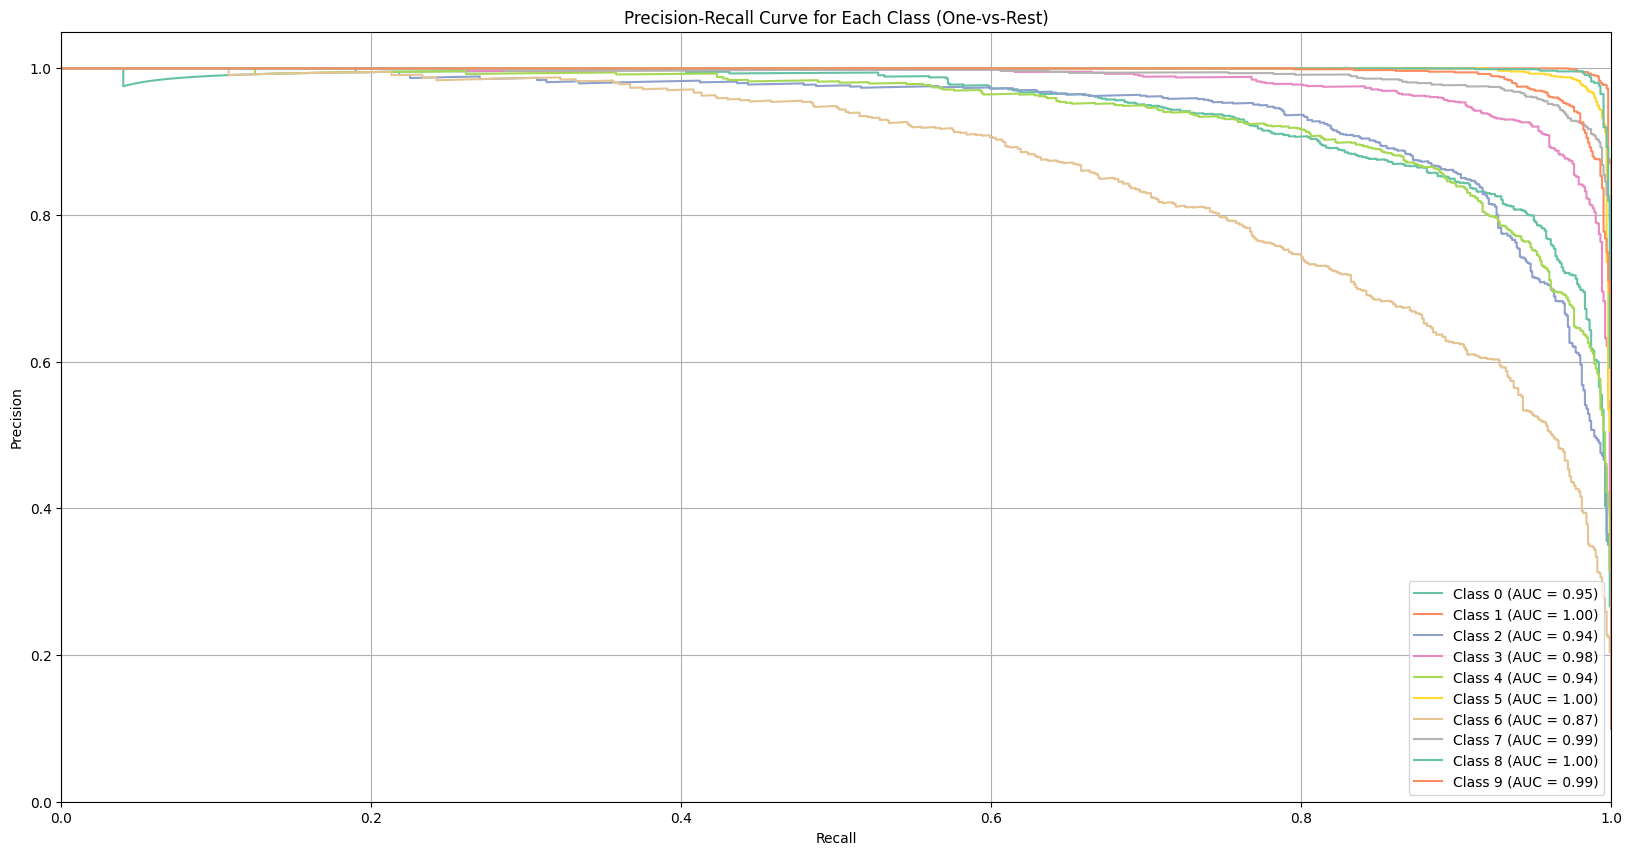

In [ ]:
print("\n--- Plotting Precision-Recall Curve ---")
class_labels_pr = [str(i) for i in range(num_classes)]

plt.figure(figsize=(20, 10))
sns.set_palette("Set2")

for i, label_str in enumerate(class_labels_pr):
    class_val = int(label_str)
    y_test_bin = np.where(y_test_keras == class_val, 1, 0)
    y_pred_score = y_pred_proba_test_keras[:, class_val]

    precision, recall, _ = precision_recall_curve(y_test_bin, y_pred_score)
    pr_auc = auc(recall, precision)

    plt.plot(recall, precision, label=f'Class {label_str} (AUC = {pr_auc:.2f})')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve for Each Class (One-vs-Rest)")
plt.legend(loc="lower right")
plt.ylim([0, 1.05])
plt.xlim([0, 1])
plt.grid(True)
plt.show()

- Interpretation: Most classes show curves very close to the top-right corner, resulting in high AUC values (many classes at $\mathbf{0.99}$ or $\mathbf{1.00}$). This confirms that the model can maintain very high precision even at high recall levels.
- Worst Performers: The curves for Class 2 (Pullover, AUC = 0.94) and especially Class 6 (Shirt, AUC = 0.87) drop off significantly earlier. The lower AUC for these classes corroborates the Classification Report, confirming that the model has the most difficulty differentiating these classes from the others, regardless of the chosen probability threshold.

**Decision Boundary in Latent Space Visualization (Test Dataset)**

The visualization of the CNN Latent Space and Decision Boundary on the test data confirms the model's feature space generalization.


--- Visualizing CNN Decision Boundary using PCA on Test Data ---
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


/tmp/ipykernel_131/4039088178.py:41: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('viridis', num_classes)


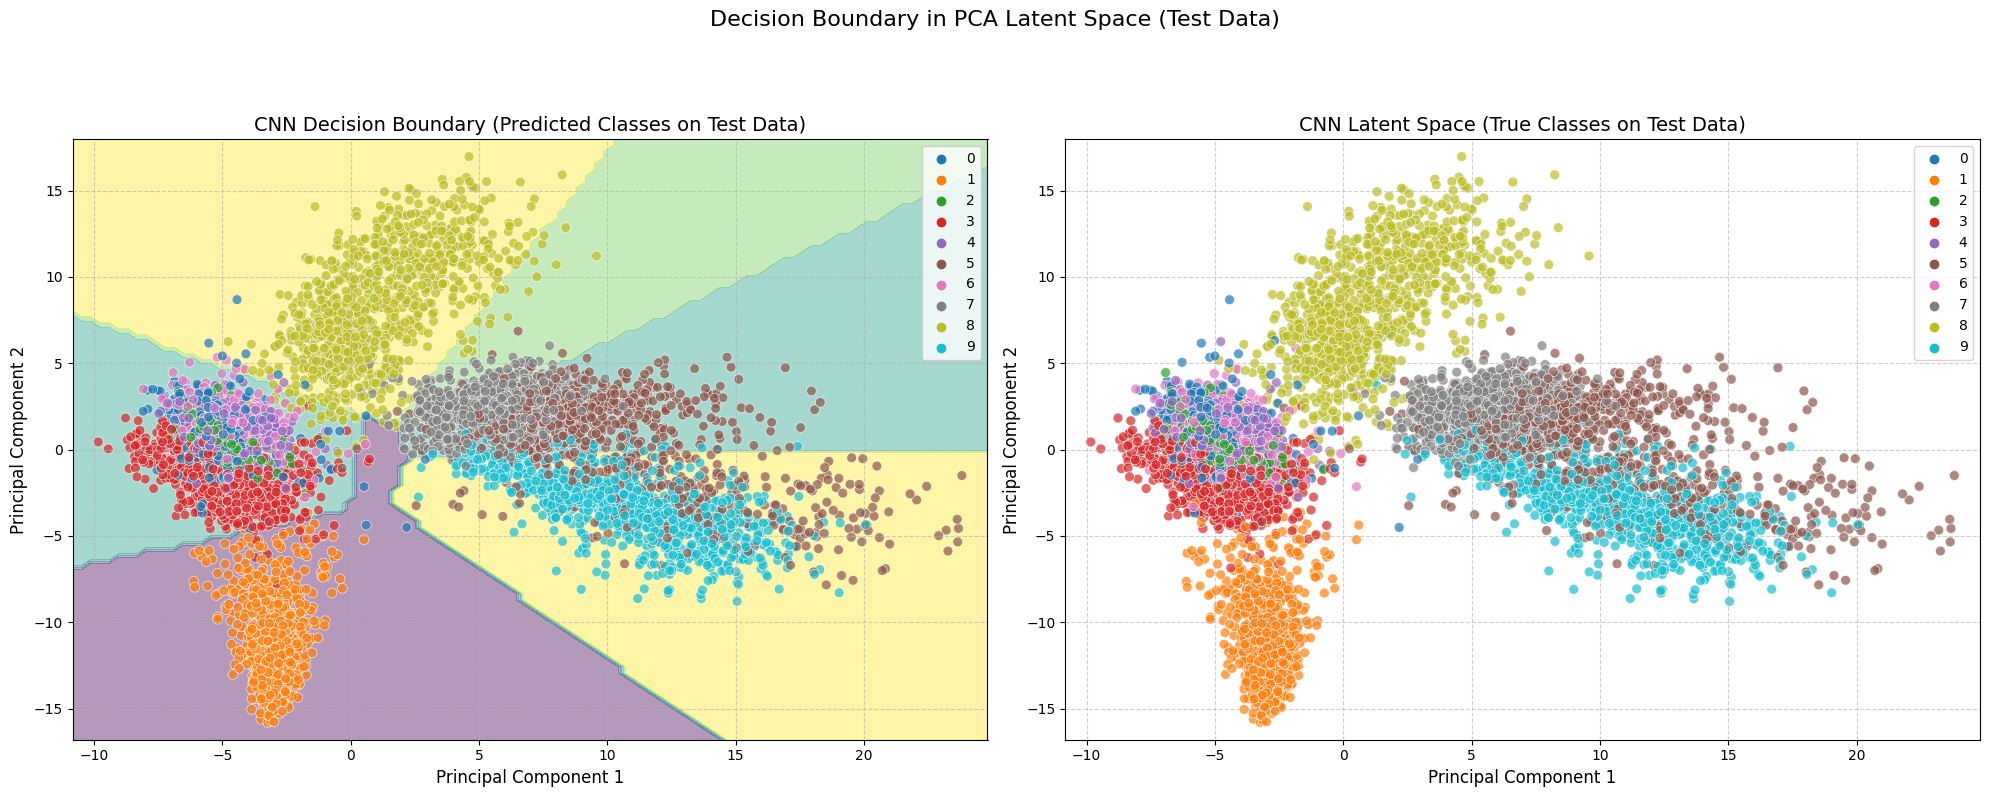

In [ ]:
print("\n--- Visualizing CNN Decision Boundary using PCA on Test Data ---")

def get_intermediate_model(model, layer_name):
    layer_index = [layer.name for layer in model.layers].index(layer_name)
    intermediate_model = Sequential(model.layers[:layer_index + 1])
    return intermediate_model

intermediate_model = get_intermediate_model(model, 'fc_intermediate_custom')
intermediate_features = intermediate_model.predict(x_test_cnn, batch_size=64)

pca = PCA(n_components=2)
pca_features = pca.fit_transform(intermediate_features)

predicted_labels = np.argmax(model.predict(x_test_cnn, batch_size=64), axis=1)

x_min, x_max = pca_features[:, 0].min() - 1, pca_features[:, 0].max() + 1
y_min, y_max = pca_features[:, 1].min() - 1, pca_features[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
meshgrid_points = np.c_[xx.ravel(), yy.ravel()]

reconstructed_features = pca.inverse_transform(meshgrid_points)

layer_index = [layer.name for layer in model.layers].index('fc_intermediate_custom')
sub_model = Sequential(model.layers[layer_index + 1:])

Z_proba = sub_model.predict(reconstructed_features, batch_size=64)
Z = np.argmax(Z_proba, axis=1).reshape(xx.shape)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
cmap = plt.cm.get_cmap('viridis', num_classes)

contourf_plot = ax1.contourf(xx, yy, Z, alpha=0.4, cmap=cmap)
sns.scatterplot(
    x=pca_features[:, 0],
    y=pca_features[:, 1],
    hue=predicted_labels,
    palette=sns.color_palette("tab10", n_colors=num_classes),
    legend='full',
    alpha=0.7,
    s=50,
    ax=ax1
)
ax1.set_title('CNN Decision Boundary (Predicted Classes on Test Data)', fontsize=14)
ax1.set_xlabel('Principal Component 1', fontsize=12)
ax1.set_ylabel('Principal Component 2', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.set_xlim(xx.min(), xx.max())
ax1.set_ylim(yy.min(), yy.max())

sns.scatterplot(
    x=pca_features[:, 0],
    y=pca_features[:, 1],
    hue=y_test_keras,
    palette=sns.color_palette("tab10", n_colors=num_classes),
    legend='full',
    alpha=0.7,
    s=50,
    ax=ax2
)
ax2.set_title('CNN Latent Space (True Classes on Test Data)', fontsize=14)
ax2.set_xlabel('Principal Component 1', fontsize=12)
ax2.set_ylabel('Principal Component 2', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.set_xlim(xx.min(), xx.max())
ax2.set_ylim(yy.min(), yy.max())

fig.suptitle('Decision Boundary in PCA Latent Space (Test Data)', fontsize=16, y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

- Latent Space (Right Plot): The true classes on the test set form tight, distinct clusters in the 2D PCA projection. This demonstrates that the features learned during training are effective at separating the test data points by class.
- Decision Boundary (Left Plot): The model's decision boundaries largely respect these natural clusters on the test data, providing a visual explanation for the high test accuracy. The minor scattered points that lie outside their respective prediction regions represent the errors observed in the Confusion Matrix.

# Conclusion

This project establishes a complete and reproducible end-to-end framework for grayscale image classification using TensorFlow CNNs on the FashionMNIST dataset. The pipeline demonstrates key deep learning practices, including data normalization, feature extraction via convolutional layers, implementation of both standard and custom architectural components, regularization through early stopping, and rigorous multi-metric performance evaluation. By incorporating visualizations of the internal mechanism through filter and decision boundary analysis, the methodology ensures both high performance and necessary transparency, providing a scalable template for more complex image recognition challenges.

# References

- [Convolution Layers Keras](https://keras.io/api/layers/convolution_layers/)
- [Image classification from scratch Keras](https://keras.io/examples/vision/image_classification_from_scratch/)
- [Convolutional Neural Networks (CNN) — Architecture Explained](https://medium.com/@draj0718/convolutional-neural-networks-cnn-architectures-explained-716fb197b243)
- [Convolutional neural network](https://en.wikipedia.org/wiki/Convolutional_neural_network)
- [An Introduction to Convolutional Neural Networks](https://arxiv.org/abs/1511.08458)
- [Introduction to Convolution Neural Network](https://www.geeksforgeeks.org/machine-learning/introduction-convolution-neural-network/)
- [Convolutional Neural Network (CNN) TensorFlow](https://www.tensorflow.org/tutorials/images/cnn)
- [Convolutional Neural Networks cheatsheet](https://stanford.edu/~shervine/teaching/cs-230/cheatsheet-convolutional-neural-networks)
- [Comprehensive Guide to CNN with Keras](https://www.kaggle.com/code/prashant111/comprehensive-guide-to-cnn-with-keras)